# 🧠 Stroke Risk Prediction — DataXplore Stage 01
## Predicting Stroke Events Using Patient Health & Lifestyle Data

**Dataset:** 9,722 patient records | 17 features | Binary classification  
**Models:** Logistic Regression · Random Forest · XGBoost · XGBoost Tuned  




---
# Section 0: Setup & Imports

In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn xgboost scipy -q
print("All packages installed successfully.")

Note: you may need to restart the kernel to use updated packages.
All packages installed successfully.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import (chi2_contingency, mannwhitneyu,
                          pointbiserialr, pearsonr, ttest_ind)
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      cross_val_score, GridSearchCV)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import (classification_report, roc_auc_score, roc_curve,
                              confusion_matrix, ConfusionMatrixDisplay,
                              precision_recall_curve, average_precision_score)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130, 'axes.titlesize': 13, 'axes.labelsize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 9, 'font.family': 'DejaVu Sans'
})
COLORS = {'no_stroke':'#4C72B0','stroke':'#DD4444',
          'teal':'#2D9B8A','orange':'#E88B2E','gray':'#888888'}
print("Libraries loaded.")

Libraries loaded.


---
# Section 1: Data Loading & Understanding

In [3]:
df_raw = pd.read_csv('healthcare_data.csv')
if 'Unnamed: 0' in df_raw.columns:
    df_raw = df_raw.drop(columns=['Unnamed: 0'])

print(f"Dataset shape: {df_raw.shape}")
print(f"Columns: {df_raw.columns.tolist()}")
print(f"\nData types:\n{df_raw.dtypes}")

Dataset shape: (9722, 17)
Columns: ['patient_id', 'gender', 'age', 'has_hypertension', 'has_heart_disease', 'marital_status', 'employment_type', 'residence', 'glucose_level', 'bmi_value', 'smoking_habit', 'stroke_event', 'age_group', 'risk_score', 'high_glucose', 'bmi_category', 'lifestyle_risk']

Data types:
patient_id             int64
gender                   str
age                  float64
has_hypertension       int64
has_heart_disease      int64
marital_status         int64
employment_type          str
residence                str
glucose_level        float64
bmi_value            float64
smoking_habit            str
stroke_event           int64
age_group                str
risk_score             int64
high_glucose           int64
bmi_category             str
lifestyle_risk           str
dtype: object


In [4]:
print("=== First 5 Rows ===")
print(df_raw.head())
print(f"\n=== Missing Values ===")
missing = df_raw.isnull().sum()
print(missing[missing > 0])
print(f"\n=== Duplicate Rows: {df_raw.duplicated().sum()} ===")
print(f"\n=== Target Distribution ===")
print(df_raw['stroke_event'].value_counts())

=== First 5 Rows ===
   patient_id gender   age  has_hypertension  has_heart_disease  \
0       30669      M   3.0                 0                  0   
1       30468      M  58.0                 1                  0   
2       16523      F   8.0                 0                  0   
3       56543      F  70.0                 0                  0   
4       46136      M  14.0                 0                  0   

   marital_status employment_type residence  glucose_level  bmi_value  \
0               0           other     Rural          95.12       18.0   
1               1         working     Urban          87.96       39.2   
2               0         working     Urban         110.89       17.6   
3               1         working     Rural          69.04       35.9   
4               0           other     Rural         161.28       19.1   

  smoking_habit  stroke_event age_group  risk_score  high_glucose  \
0       unknown             0     young           0             0   

---
# Section 2: Data Preparation
## 2.1 Remove Duplicates

In [5]:
print(f"Before deduplication: {df_raw.shape[0]:,} rows")
df = df_raw.drop_duplicates()
print(f"After deduplication:  {df.shape[0]:,} rows")
print(f"Removed:              {df_raw.shape[0] - df.shape[0]:,} duplicate rows")

Before deduplication: 9,722 rows
After deduplication:  5,110 rows
Removed:              4,612 duplicate rows


## 2.2 Missing Value Analysis & Imputation

In [6]:
print("BMI missing values by stroke group:")
print(df.groupby('stroke_event')['bmi_value'].apply(lambda x: x.isnull().sum()))
print(f"\nBMI missing by BMI category:")
print(df[df['bmi_value'].isnull()]['bmi_category'].value_counts())
print(f"\nMedian BMI overall: {df['bmi_value'].median():.2f}")
print(f"Median BMI for obese patients: {df[df['bmi_category']=='obese']['bmi_value'].median():.2f}")

BMI missing values by stroke group:
stroke_event
0    161
1     40
Name: bmi_value, dtype: int64

BMI missing by BMI category:
bmi_category
obese    201
Name: count, dtype: int64

Median BMI overall: 28.10
Median BMI for obese patients: 34.70


## 2.3 Feature Audit — Drop Confounded Proxies

In [7]:
le_temp = LabelEncoder()
emp_encoded = le_temp.fit_transform(df['employment_type'])
r, p = pearsonr(emp_encoded, df['age'])
print(f"employment_type vs age: Pearson r = {r:.3f}, p = {p:.6f}")
print("\nMean age by employment_type:")
print(df.groupby('employment_type')['age'].mean().round(1))
print("\nStroke rate by employment_type:")
print((df.groupby('employment_type')['stroke_event'].mean()*100).round(2))
print("\nVerdict: 'other' = mostly children (encodes age, not clinical risk) -> will be dropped from model")

employment_type vs age: Pearson r = 0.191, p = 0.000000

Mean age by employment_type:
employment_type
government    50.9
other          7.1
working       48.7
Name: age, dtype: float64

Stroke rate by employment_type:
employment_type
government    5.02
other         0.28
working       5.72
Name: stroke_event, dtype: float64

Verdict: 'other' = mostly children (encodes age, not clinical risk) -> will be dropped from model


## 2.4 Leakage-Safe Train/Test Split, Imputation & Encoding

In [8]:
df_model = df.copy()

# One-hot encode nominal categories
df_model = pd.get_dummies(df_model,
    columns=['gender','residence','smoking_habit'], drop_first=True)

# Ordinal encode ordered categories
ordinal_maps = {
    'age_group':      {'young':0,'middle':1,'senior':2},
    'bmi_category':   {'underweight':0,'normal':1,'overweight':2,'obese':3},
    'lifestyle_risk': {'low':0,'medium':1,'high':2}
}
for col, mapping in ordinal_maps.items():
    df_model[col] = df_model[col].map(mapping)

# Drop non-clinical proxy (employment_type encodes child/adult, not clinical risk)
df_model = df_model.drop(columns=['employment_type'])

X = df_model.drop(columns=['patient_id','stroke_event'])
y = df_model['stroke_event']

# Stratified split BEFORE any imputation (leakage-safe)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Leakage-safe BMI imputation: compute from train only, apply to both
bmi_train_median = X_train['bmi_value'].median()
X_train = X_train.copy()
X_test  = X_test.copy()
X_train['bmi_value'] = X_train['bmi_value'].fillna(bmi_train_median)
X_test['bmi_value']  = X_test['bmi_value'].fillna(bmi_train_median)

print(f"Train: {X_train.shape[0]:,} samples | Test: {X_test.shape[0]:,} samples")
print(f"Features: {X_train.shape[1]}")
print(f"Stroke prevalence - Train: {y_train.mean()*100:.2f}% | Test: {y_test.mean()*100:.2f}%")
print(f"Class imbalance ratio: {(y_train==0).sum()/(y_train==1).sum():.1f}:1")
print(f"BMI imputation value (train median): {bmi_train_median:.2f}")
print(f"All features in X_train ({X_train.shape[1]} total):{X_train.columns.tolist()}")


Train: 4,088 samples | Test: 1,022 samples
Features: 16
Stroke prevalence - Train: 4.87% | Test: 4.89%
Class imbalance ratio: 19.5:1
BMI imputation value (train median): 28.00
All features in X_train (16 total):['age', 'has_hypertension', 'has_heart_disease', 'marital_status', 'glucose_level', 'bmi_value', 'age_group', 'risk_score', 'high_glucose', 'bmi_category', 'lifestyle_risk', 'gender_M', 'residence_Urban', 'smoking_habit_ex_smoker', 'smoking_habit_non_smoker', 'smoking_habit_unknown']


---
# Section 3: Descriptive Statistics

In [9]:
print("=== Numerical Variable Summary ===")
print(df[['age','glucose_level','bmi_value','risk_score']].describe().round(2))

print("\n=== Stroke Rate by Key Categorical Variables ===")
for col in ['gender','has_hypertension','has_heart_disease',
            'age_group','bmi_category','smoking_habit','lifestyle_risk']:
    grouped = df.groupby(col)['stroke_event'].agg(['mean','sum','count'])
    grouped.columns = ['Stroke Rate','Stroke Count','Total']
    grouped['Stroke Rate'] = (grouped['Stroke Rate']*100).round(2).astype(str) + '%'
    print(f"\n--- {col} ---")
    print(grouped)

=== Numerical Variable Summary ===
           age  glucose_level  bmi_value  risk_score
count  5110.00        5110.00    4909.00     5110.00
mean     43.23         106.15      28.89        0.15
std      22.61          45.28       7.85        0.39
min       0.08          55.12      10.30        0.00
25%      25.00          77.24      23.50        0.00
50%      45.00          91.88      28.10        0.00
75%      61.00         114.09      33.10        0.00
max      82.00         271.74      97.60        2.00

=== Stroke Rate by Key Categorical Variables ===

--- gender ---
       Stroke Rate  Stroke Count  Total
gender                                 
F            4.71%           141   2995
M            5.11%           108   2115

--- has_hypertension ---
                 Stroke Rate  Stroke Count  Total
has_hypertension                                 
0                      3.97%           183   4612
1                     13.25%            66    498

--- has_heart_disease ---
         

In [10]:
print("=== Numerical Comparison: Stroke vs No Stroke ===")
for col in ['age','glucose_level','bmi_value']:
    s  = df[df['stroke_event']==1][col]
    ns = df[df['stroke_event']==0][col]
    print(f"\n{col}:")
    print(f"  Stroke:    mean={s.mean():.2f}, median={s.median():.2f}, std={s.std():.2f}")
    print(f"  No Stroke: mean={ns.mean():.2f}, median={ns.median():.2f}, std={ns.std():.2f}")

=== Numerical Comparison: Stroke vs No Stroke ===

age:
  Stroke:    mean=67.73, median=71.00, std=12.73
  No Stroke: mean=41.97, median=43.00, std=22.29

glucose_level:
  Stroke:    mean=132.54, median=105.22, std=61.92
  No Stroke: mean=104.80, median=91.47, std=43.85

bmi_value:
  Stroke:    mean=30.47, median=29.70, std=6.33
  No Stroke: mean=28.82, median=28.00, std=7.91


---
# Section 4: Data Visualization

## Figure 1: Stroke Event Distribution

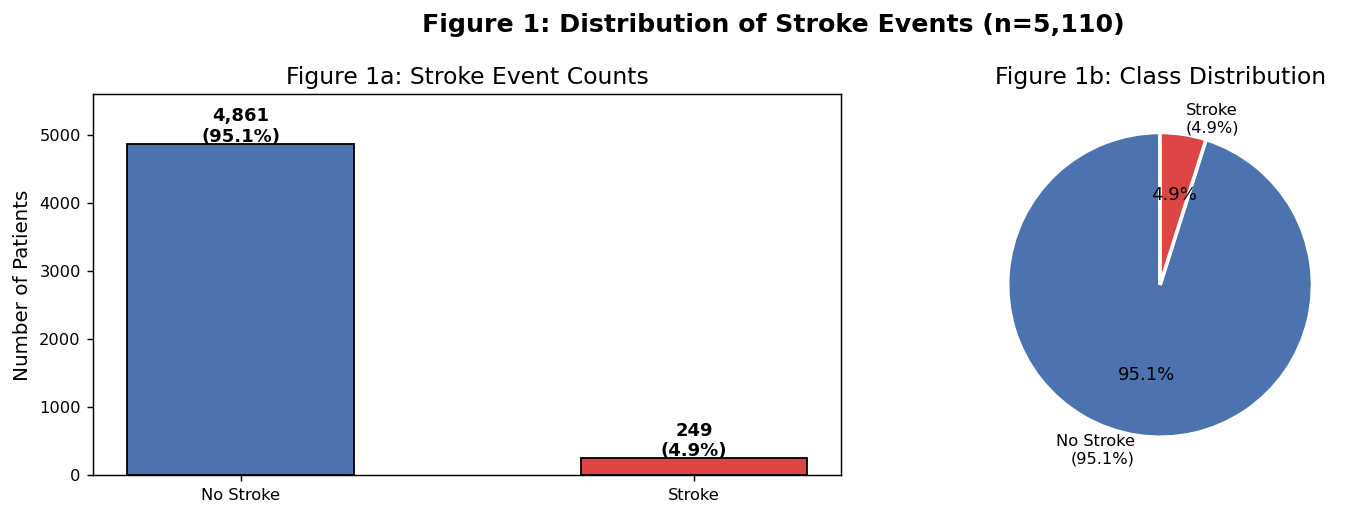

Saved: fig1_stroke_distribution.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df['stroke_event'].value_counts()
bars = axes[0].bar(['No Stroke','Stroke'], counts.values,
    color=[COLORS['no_stroke'],COLORS['stroke']], edgecolor='black', width=0.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
        f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Figure 1a: Stroke Event Counts')
axes[0].set_ylabel('Number of Patients')
axes[0].set_ylim(0, counts.max()*1.15)

axes[1].pie(counts.values, labels=['No Stroke\n(95.1%)','Stroke\n(4.9%)'],
    colors=[COLORS['no_stroke'],COLORS['stroke']],
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Figure 1b: Class Distribution')

plt.suptitle('Figure 1: Distribution of Stroke Events (n=5,110)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_stroke_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig1_stroke_distribution.png")

## Figure 2: Stroke Rate by Risk Factor Categories

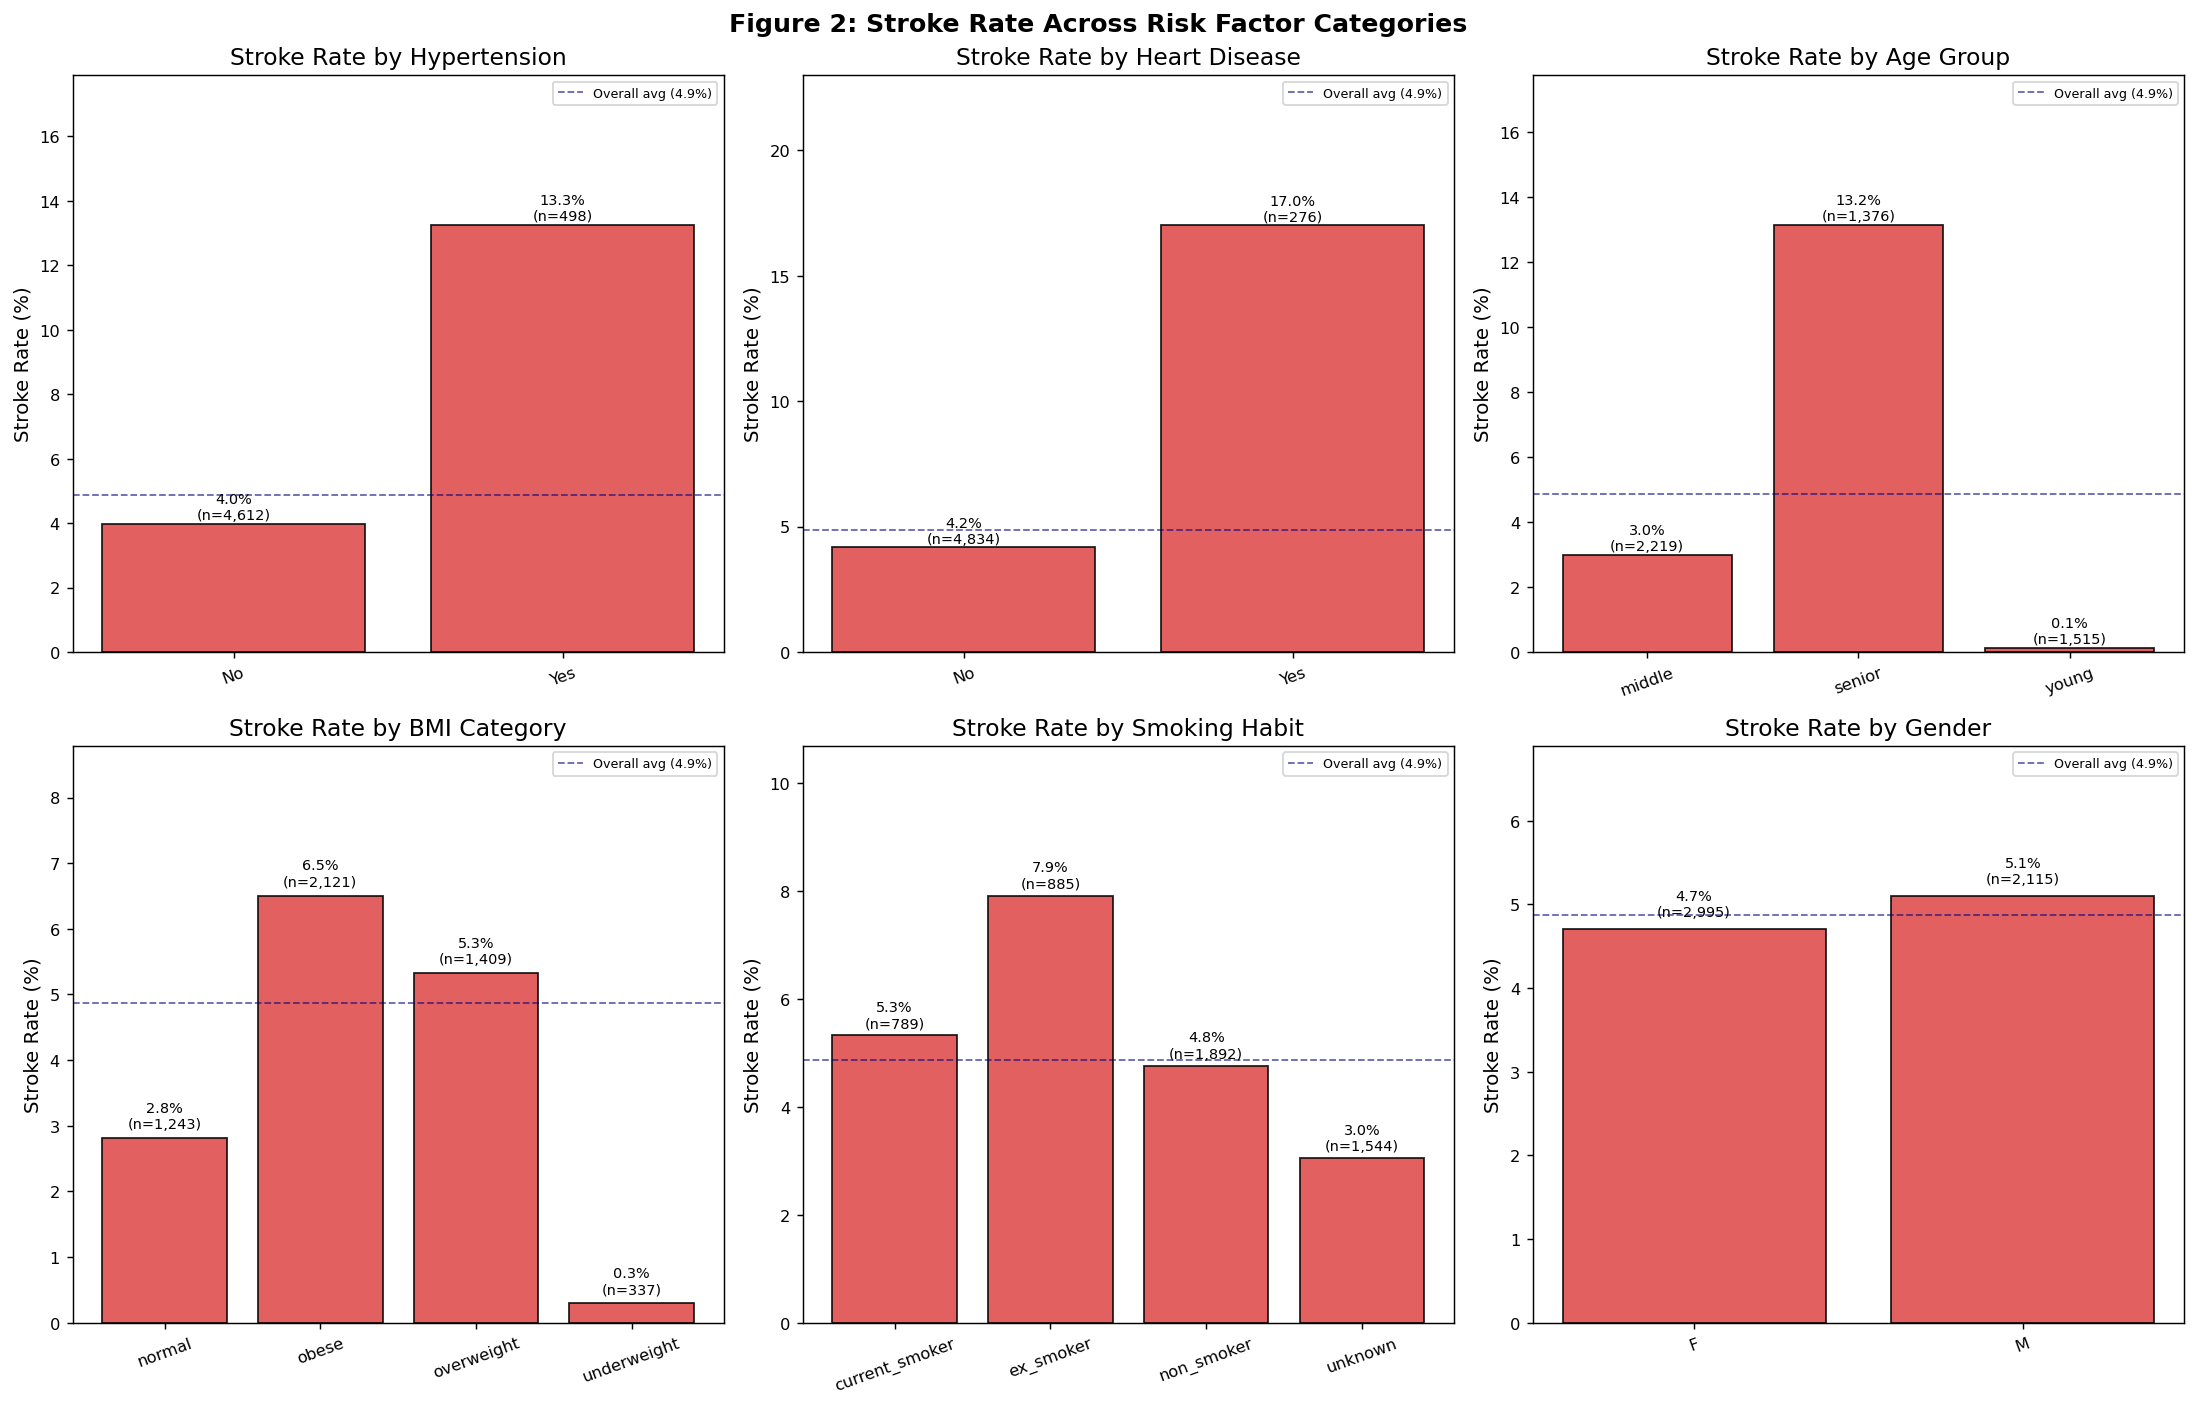

Saved: fig2_stroke_by_categories.png


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(17, 11))
cat_data = [
    ('has_hypertension','Hypertension',{0:'No',1:'Yes'}),
    ('has_heart_disease','Heart Disease',{0:'No',1:'Yes'}),
    ('age_group','Age Group',None),
    ('bmi_category','BMI Category',None),
    ('smoking_habit','Smoking Habit',None),
    ('gender','Gender',None),
]
for ax, (col, label, rename) in zip(axes.flatten(), cat_data):
    data = df.copy()
    if rename:
        data[col] = data[col].map(rename)
    stroke_rate = data.groupby(col)['stroke_event'].mean() * 100
    counts_total = data.groupby(col).size()
    bars = ax.bar(stroke_rate.index, stroke_rate.values,
        color=COLORS['stroke'], alpha=0.85, edgecolor='black')
    for bar, val, n in zip(bars, stroke_rate.values, counts_total.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.15,
            f'{val:.1f}%\n(n={n:,})', ha='center', fontsize=8)
    ax.axhline(df['stroke_event'].mean()*100, color='navy', linestyle='--',
        linewidth=1, alpha=0.6,
        label=f'Overall avg ({df["stroke_event"].mean()*100:.1f}%)')
    ax.set_title(f'Stroke Rate by {label}')
    ax.set_ylabel('Stroke Rate (%)')
    ax.set_ylim(0, stroke_rate.max()*1.35)
    ax.tick_params(axis='x', rotation=20)
    ax.legend(fontsize=7)

plt.suptitle('Figure 2: Stroke Rate Across Risk Factor Categories',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_stroke_by_categories.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig2_stroke_by_categories.png")

## Figure 3: Age Distribution by Stroke Event

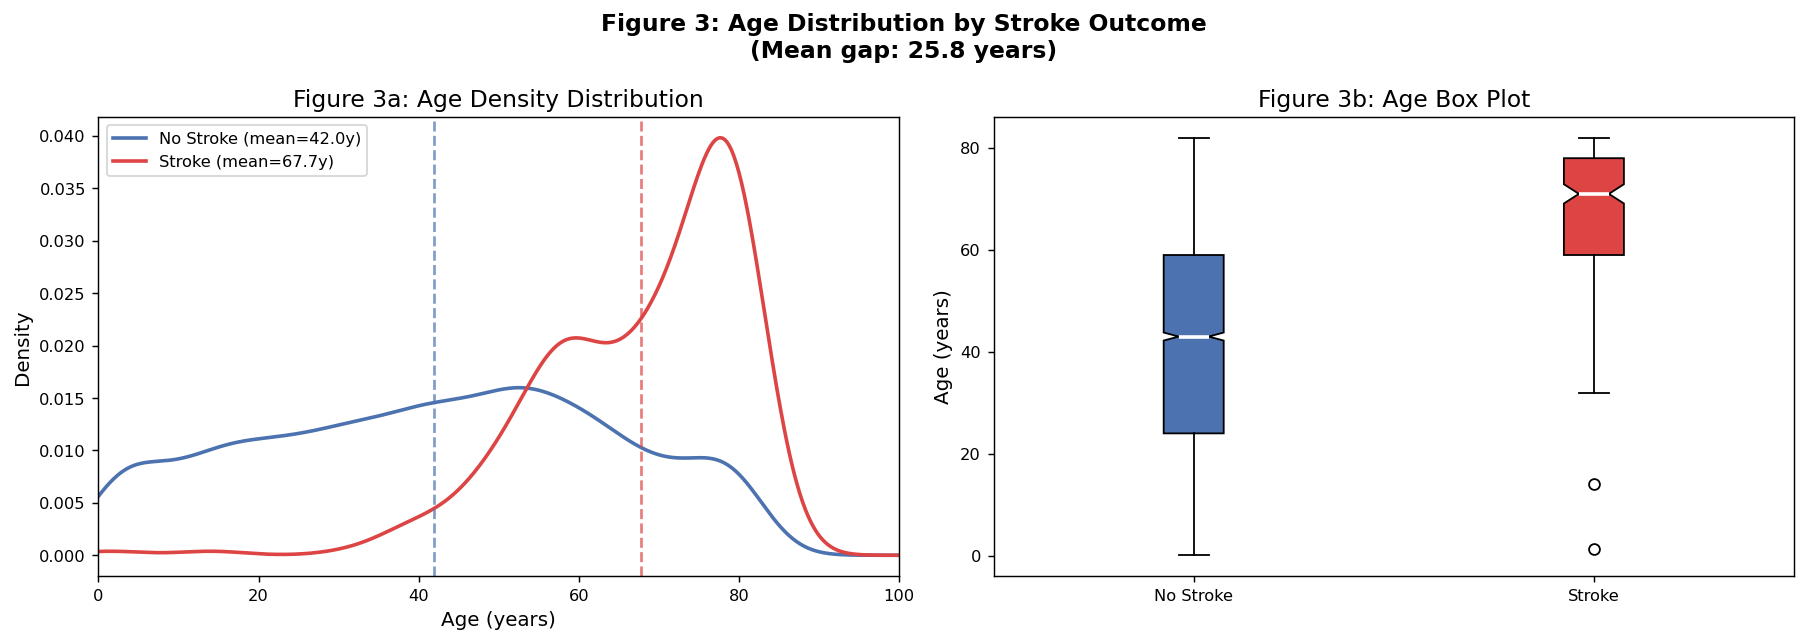

Saved: fig3_age_distribution.png
Mean age — Stroke: 67.7 | No Stroke: 42.0 | Gap: 25.8 years


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
mean_s  = df[df['stroke_event']==1]['age'].mean()
mean_ns = df[df['stroke_event']==0]['age'].mean()

df[df['stroke_event']==0]['age'].plot(kind='kde', ax=axes[0],
    label=f'No Stroke (mean={mean_ns:.1f}y)',
    color=COLORS['no_stroke'], linewidth=2)
df[df['stroke_event']==1]['age'].plot(kind='kde', ax=axes[0],
    label=f'Stroke (mean={mean_s:.1f}y)',
    color=COLORS['stroke'], linewidth=2)
axes[0].axvline(mean_s,  color=COLORS['stroke'],    linestyle='--', alpha=0.7)
axes[0].axvline(mean_ns, color=COLORS['no_stroke'], linestyle='--', alpha=0.7)
axes[0].set_xlim(0, 100)
axes[0].set_title('Figure 3a: Age Density Distribution')
axes[0].set_xlabel('Age (years)'); axes[0].set_ylabel('Density')
axes[0].legend()

data_box = [df[df['stroke_event']==0]['age'].dropna(),
            df[df['stroke_event']==1]['age'].dropna()]
bp = axes[1].boxplot(data_box, patch_artist=True, notch=True,
                      labels=['No Stroke','Stroke'])
bp['boxes'][0].set_facecolor(COLORS['no_stroke'])
bp['boxes'][1].set_facecolor(COLORS['stroke'])
for m in bp['medians']:
    m.set_color('white'); m.set_linewidth(2)
axes[1].set_title('Figure 3b: Age Box Plot')
axes[1].set_ylabel('Age (years)')

plt.suptitle(f'Figure 3: Age Distribution by Stroke Outcome'
             f'\n(Mean gap: {mean_s-mean_ns:.1f} years)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: fig3_age_distribution.png")
print(f"Mean age — Stroke: {mean_s:.1f} | No Stroke: {mean_ns:.1f} | Gap: {mean_s-mean_ns:.1f} years")

## Figure 4: Glucose & BMI Distributions by Stroke

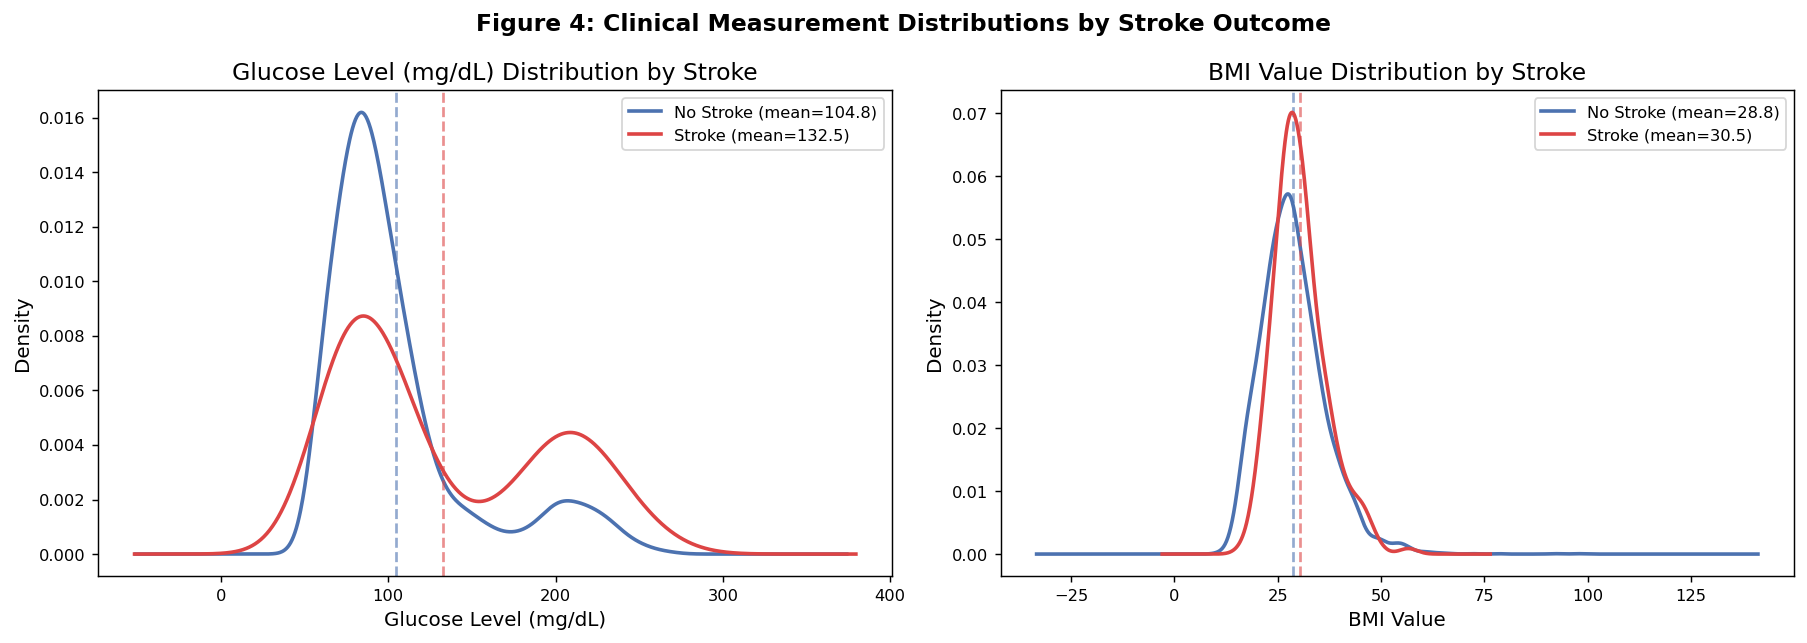

Saved: fig4_clinical_distributions.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, xlabel in zip(axes,
    ['glucose_level','bmi_value'],
    ['Glucose Level (mg/dL)','BMI Value']):
    for event, color, label in [(0,COLORS['no_stroke'],'No Stroke'),
                                  (1,COLORS['stroke'],'Stroke')]:
        subset = df[df['stroke_event']==event][col].dropna()
        subset.plot(kind='kde', ax=ax, color=color, linewidth=2,
            label=f'{label} (mean={subset.mean():.1f})')
        ax.axvline(subset.mean(), color=color, linestyle='--', alpha=0.6)
    ax.set_xlabel(xlabel); ax.set_ylabel('Density')
    ax.set_title(f'{xlabel} Distribution by Stroke')
    ax.legend()
plt.suptitle('Figure 4: Clinical Measurement Distributions by Stroke Outcome',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_clinical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig4_clinical_distributions.png")

## Figure 5: Correlation Heatmap with Significance Markers

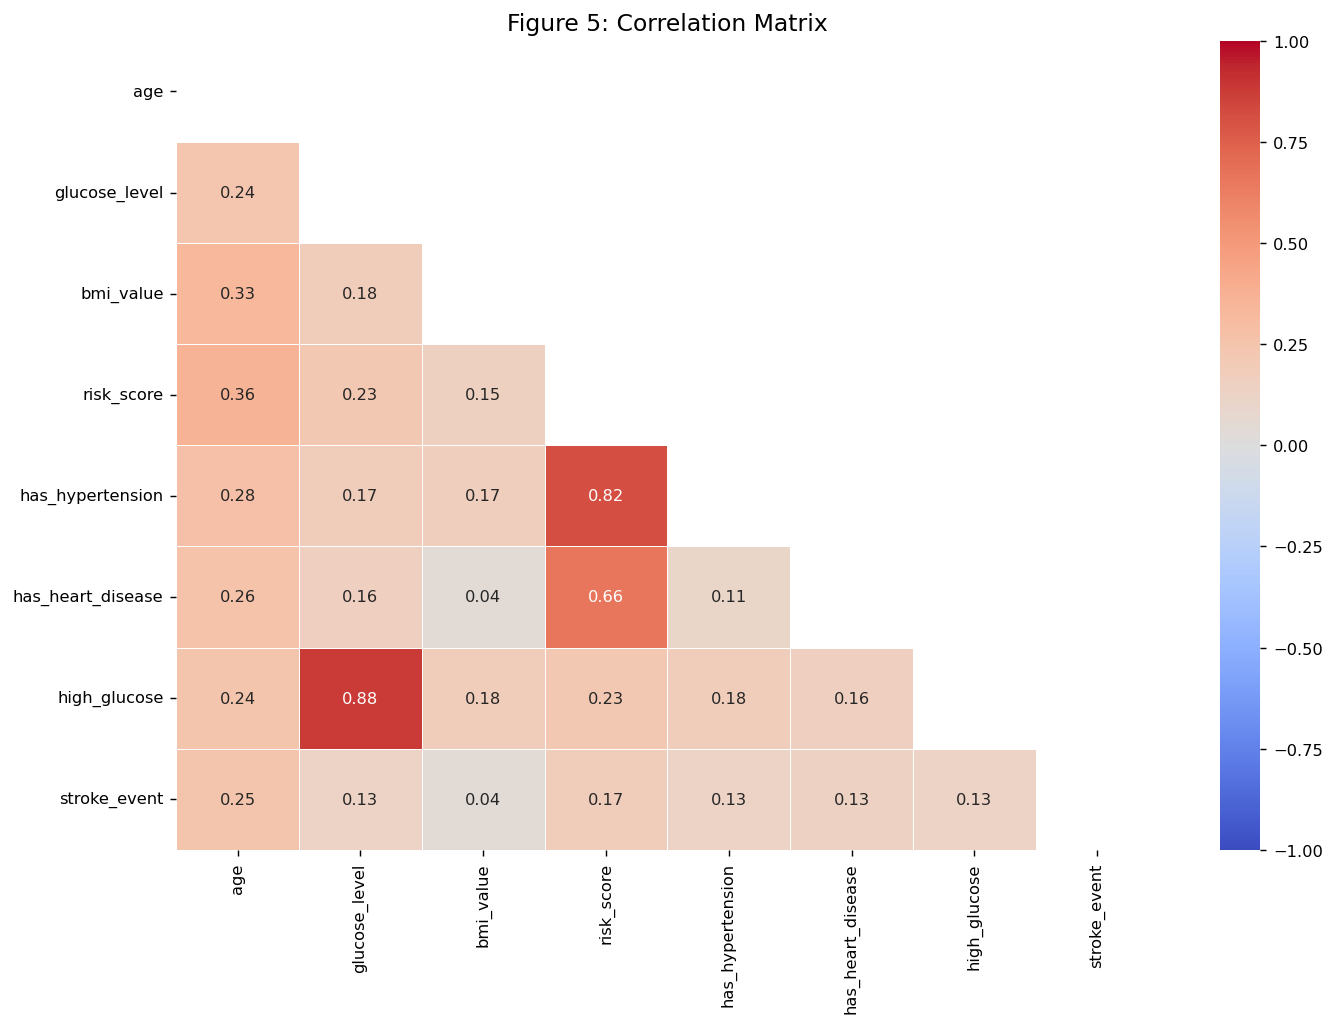

Saved: fig5_correlation_heatmap.png


In [45]:
num_cols_corr = ['age','glucose_level','bmi_value','risk_score',
                  'has_hypertension','has_heart_disease','high_glucose','stroke_event']

corr_matrix = df[num_cols_corr].corr()

annot = corr_matrix.round(2).astype(str)

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, annot=annot, fmt='', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, linewidths=0.5, annot_kws={'size':9})

plt.title('Figure 5: Correlation Matrix',
          fontsize=13)

plt.tight_layout()
plt.savefig('fig5_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: fig5_correlation_heatmap.png")

In [16]:
# (Correlation heatmap with significance markers already produced above)
print("Correlation heatmap already saved as fig5_correlation_heatmap.png")


Correlation heatmap already saved as fig5_correlation_heatmap.png


## Figure 6: Pairwise Scatter Plots

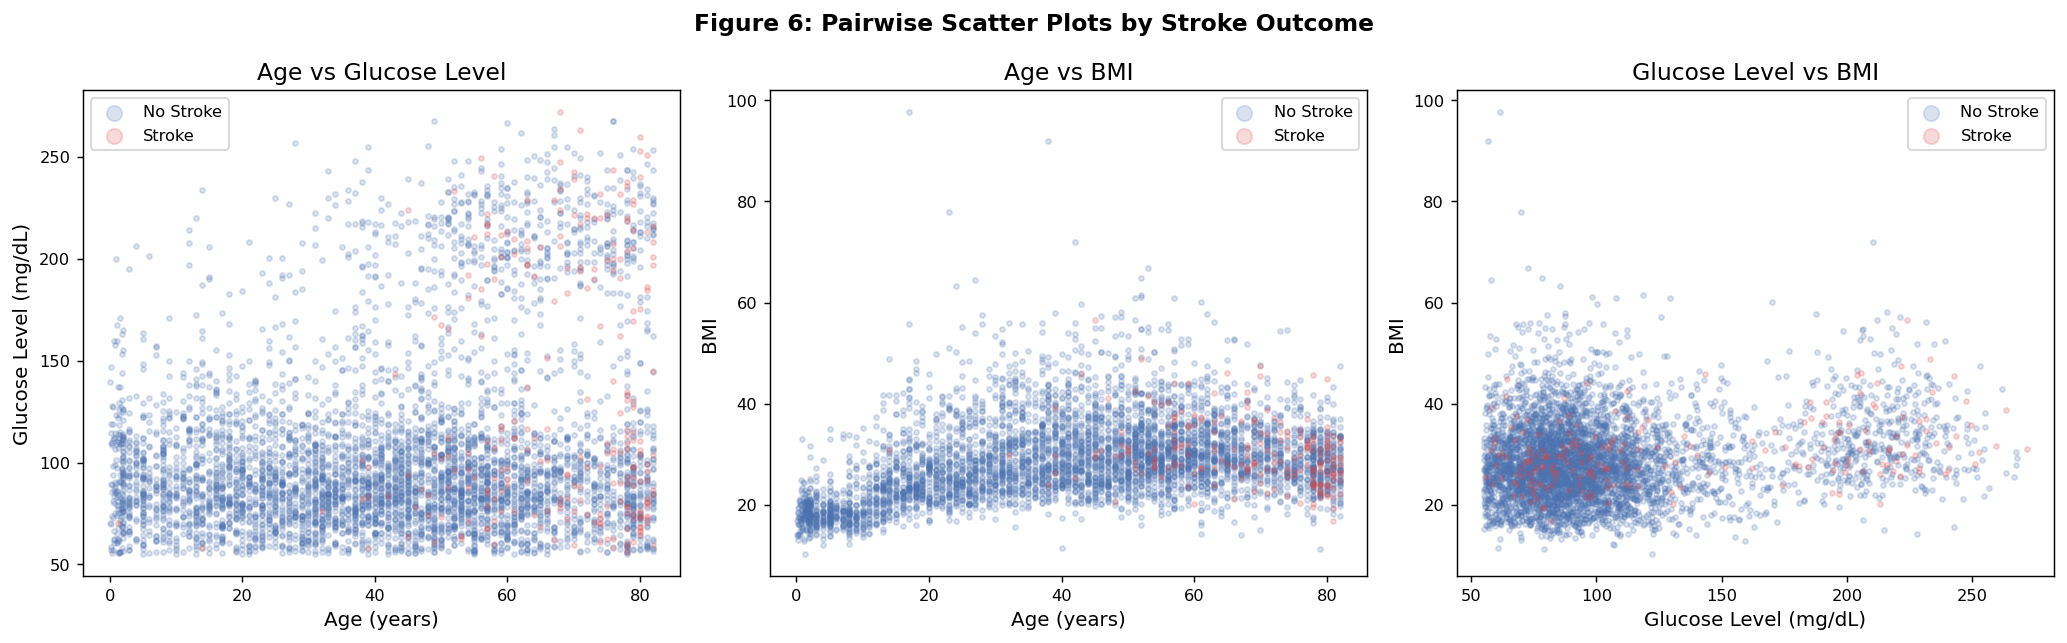

Saved: fig6_scatter_plots.png


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
pairs   = [('age','glucose_level'),('age','bmi_value'),('glucose_level','bmi_value')]
xlabels = ['Age (years)','Age (years)','Glucose Level (mg/dL)']
ylabels = ['Glucose Level (mg/dL)','BMI','BMI']

for ax, (x,y_col), xl, yl in zip(axes, pairs, xlabels, ylabels):
    for event, color, label in [(0,COLORS['no_stroke'],'No Stroke'),
                                  (1,COLORS['stroke'],'Stroke')]:
        subset = df[df['stroke_event']==event]
        ax.scatter(subset[x], subset[y_col], alpha=0.2, s=8,
                   color=color, label=label)
    ax.set_xlabel(xl); ax.set_ylabel(yl)
    ax.set_title(f'{xl.split("(")[0].strip()} vs {yl.split("(")[0].strip()}')
    ax.legend(markerscale=3, fontsize=9)

plt.suptitle('Figure 6: Pairwise Scatter Plots by Stroke Outcome',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig6_scatter_plots.png")

## Figure 7: Risk Profile Histograms

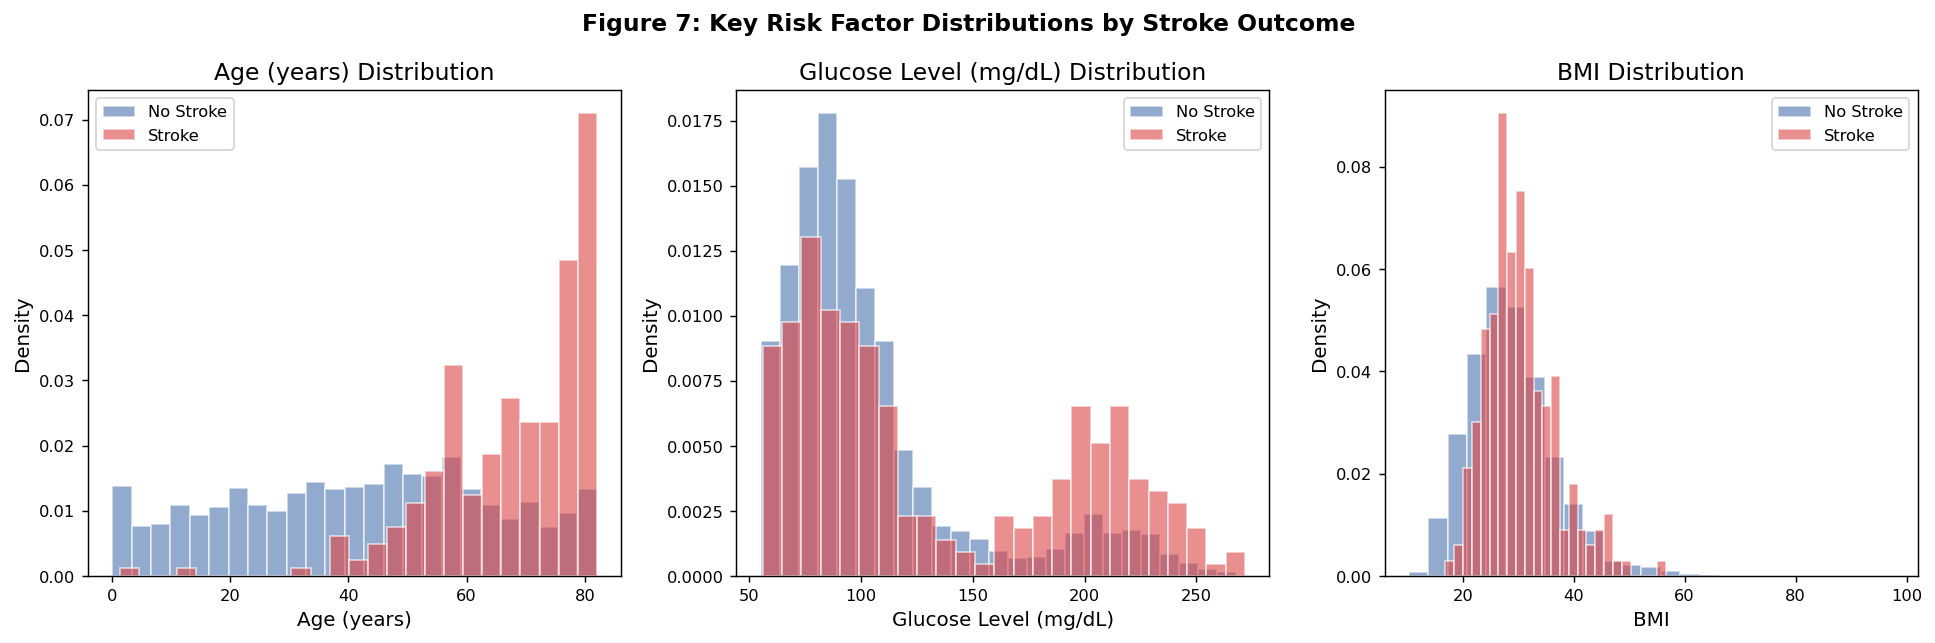

Saved: fig7_risk_profiles.png


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col, xlabel in zip(axes,
    ['age','glucose_level','bmi_value'],
    ['Age (years)','Glucose Level (mg/dL)','BMI']):
    for event, color, label in [(0,COLORS['no_stroke'],'No Stroke'),
                                  (1,COLORS['stroke'],'Stroke')]:
        ax.hist(df[df['stroke_event']==event][col].dropna(), bins=25,
                alpha=0.6, color=color, label=label, density=True, edgecolor='white')
    ax.set_xlabel(xlabel); ax.set_ylabel('Density')
    ax.set_title(f'{xlabel} Distribution')
    ax.legend()

plt.suptitle('Figure 7: Key Risk Factor Distributions by Stroke Outcome',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig7_risk_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig7_risk_profiles.png")

## Figure 8: Stroke Rate Heatmap — Age × Glucose Risk Zones

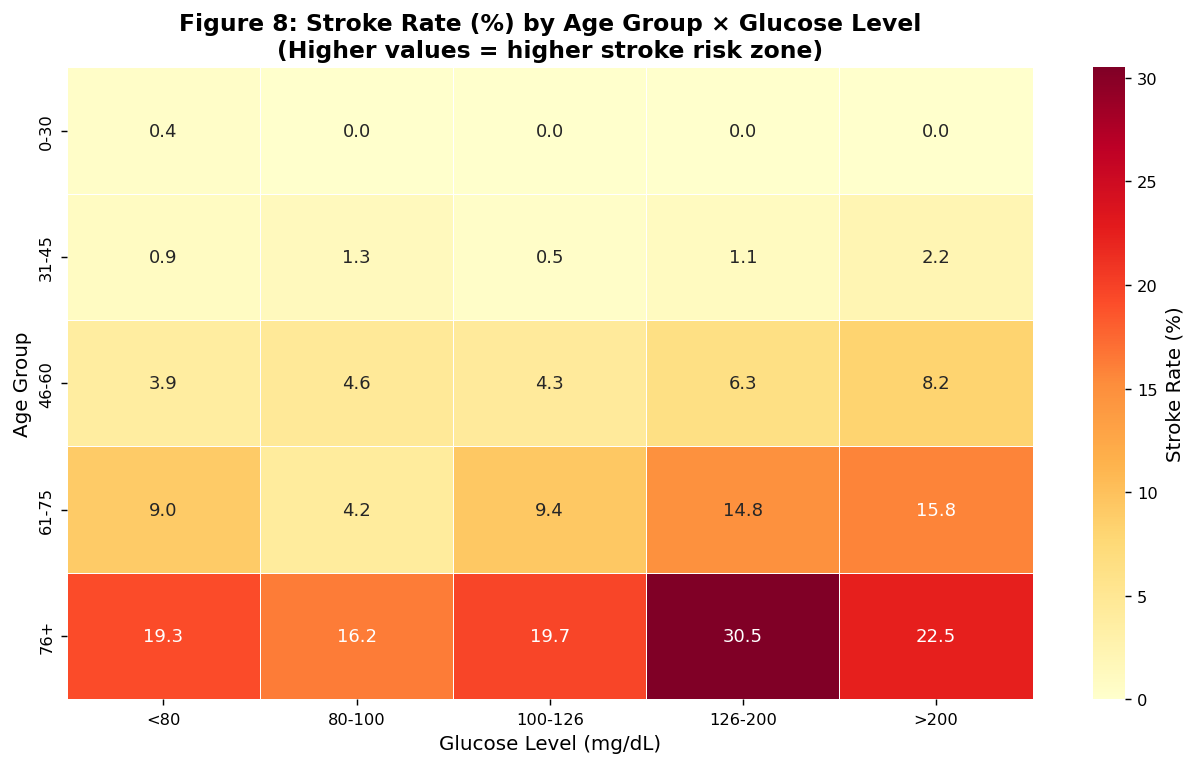

Saved: fig8_age_glucose_heatmap.png


In [19]:
# Bin age and glucose into zones for heatmap
df_heat = df.copy()
df_heat['age_bin'] = pd.cut(df_heat['age'], bins=[0,30,45,60,75,100],
    labels=['0-30','31-45','46-60','61-75','76+'])
df_heat['glucose_bin'] = pd.cut(df_heat['glucose_level'],
    bins=[0,80,100,126,200,300],
    labels=['<80','80-100','100-126','126-200','>200'])

pivot = df_heat.groupby(['age_bin','glucose_bin'])['stroke_event'].mean().unstack() * 100

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label':'Stroke Rate (%)'})
plt.title('Figure 8: Stroke Rate (%) by Age Group × Glucose Level\n'
          '(Higher values = higher stroke risk zone)', fontsize=13, fontweight='bold')
plt.xlabel('Glucose Level (mg/dL)')
plt.ylabel('Age Group')
plt.tight_layout()
plt.savefig('fig8_age_glucose_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig8_age_glucose_heatmap.png")

## Figure 9: Grouped Bar — Stroke Rate by BMI Category & Hypertension

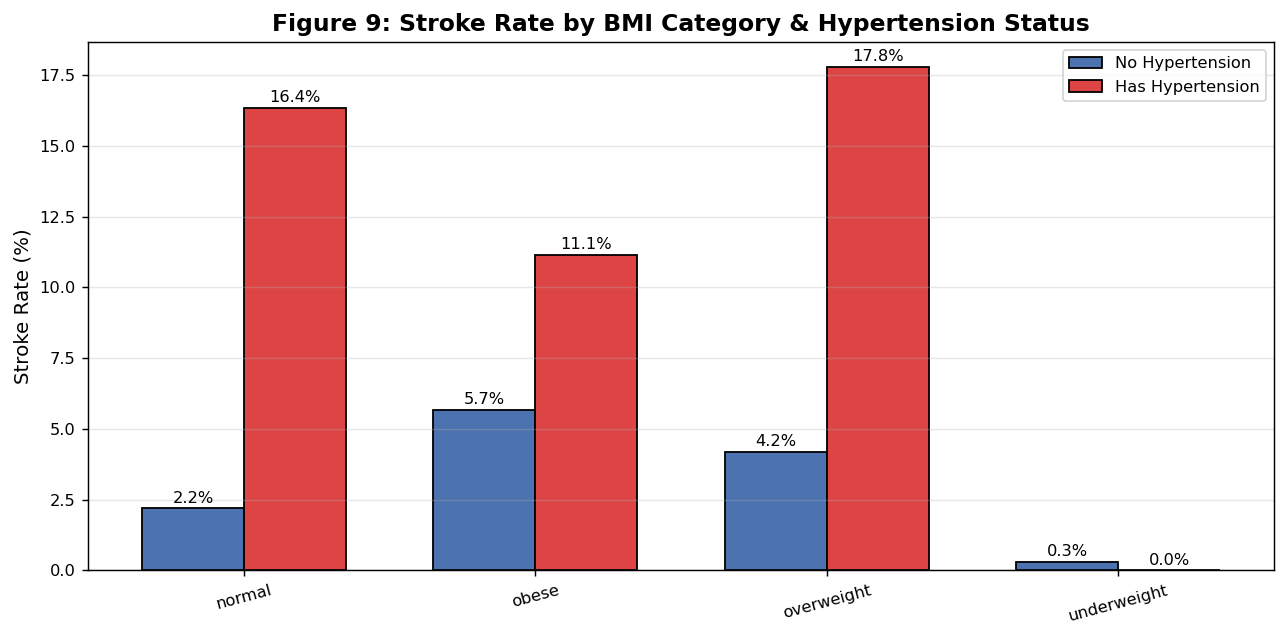

Saved: fig9_bmi_hypertension.png


In [20]:
pivot2 = df.groupby(['bmi_category','has_hypertension'])['stroke_event'].mean().unstack()*100
pivot2.columns = ['No Hypertension','Has Hypertension']

x = np.arange(len(pivot2.index))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, pivot2['No Hypertension'], width,
               label='No Hypertension', color=COLORS['no_stroke'], edgecolor='black')
bars2 = ax.bar(x + width/2, pivot2['Has Hypertension'], width,
               label='Has Hypertension', color=COLORS['stroke'], edgecolor='black')

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            f'{bar.get_height():.1f}%', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            f'{bar.get_height():.1f}%', ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(pivot2.index, rotation=15)
ax.set_ylabel('Stroke Rate (%)')
ax.set_title('Figure 9: Stroke Rate by BMI Category & Hypertension Status',
             fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig9_bmi_hypertension.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig9_bmi_hypertension.png")

---
# Section 5: Statistical Analysis

## 5.1 T-tests & Mann-Whitney U Tests

In [21]:
print("="*65)
print(f"{'Variable':<18} {'T-stat':>8} {'T p-val':>10} {'U p-val':>10} {'r (pb)':>8} {'Sig':>5}")
print("="*65)

stat_results = {}
for col in ['age','glucose_level','bmi_value','risk_score']:
    s  = df[df['stroke_event']==1][col].dropna()
    ns = df[df['stroke_event']==0][col].dropna()
    t_stat, t_p = ttest_ind(s, ns)
    _, u_p      = mannwhitneyu(s, ns, alternative='two-sided')
    rpb, _      = pointbiserialr(df['stroke_event'],
                                  df[col].fillna(df[col].median()))
    stat_results[col] = {'t':t_stat,'t_p':t_p,'u_p':u_p,'rpb':rpb,
                          'mean_s':s.mean(),'mean_ns':ns.mean()}
    sig = '***' if t_p<0.001 else '**' if t_p<0.01 else '*' if t_p<0.05 else 'ns'
    print(f"{col:<18} {t_stat:>8.3f} {t_p:>10.6f} {u_p:>10.6f} {rpb:>8.4f} {sig:>5}")

print("\nMean values (Stroke vs No Stroke):")
for col, r in stat_results.items():
    print(f"  {col:<18}: {r['mean_s']:.2f} vs {r['mean_ns']:.2f}")

Variable             T-stat    T p-val    U p-val   r (pb)   Sig
age                  18.081   0.000000   0.000000   0.2453   ***
glucose_level         9.513   0.000000   0.000000   0.1319   ***
bmi_value             2.971   0.002983   0.000103   0.0361    **
risk_score           12.675   0.000000   0.000000   0.1746   ***

Mean values (Stroke vs No Stroke):
  age               : 67.73 vs 41.97
  glucose_level     : 132.54 vs 104.80
  bmi_value         : 30.47 vs 28.82
  risk_score        : 0.45 vs 0.14


## 5.2 Chi-Square Tests & Cramér's V

In [22]:
def cramers_v(col1, col2, dataframe):
    ct = pd.crosstab(dataframe[col1], dataframe[col2])
    chi2, _, _, _ = chi2_contingency(ct)
    n = ct.sum().sum()
    return np.sqrt(chi2 / (n * (min(ct.shape)-1)))

cat_test_cols = ['has_hypertension','has_heart_disease','high_glucose',
                  'age_group','bmi_category','smoking_habit',
                  'lifestyle_risk','marital_status','gender','residence']
cv_results = {}
print("="*70)
print(f"{'Variable':<25} {'Chi2':>8} {'p-value':>10} {'Sig':>5} {'CramerV':>9} {'Strength':>10}")
print("="*70)
for col in cat_test_cols:
    ct = pd.crosstab(df[col], df['stroke_event'])
    chi2, p, _, _ = chi2_contingency(ct)
    v = cramers_v(col, 'stroke_event', df)
    cv_results[col] = v
    sig      = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
    strength = 'Strong' if v>=0.3 else 'Moderate' if v>=0.1 else 'Weak'
    print(f"{col:<25} {chi2:>8.3f} {p:>10.6f} {sig:>5} {v:>9.4f} {strength:>10}")
print("\nNote: *** p<0.001  ** p<0.01  * p<0.05")

Variable                      Chi2    p-value   Sig   CramerV   Strength
has_hypertension            81.605   0.000000   ***    0.1264   Moderate
has_heart_disease           90.260   0.000000   ***    0.1329   Moderate
high_glucose                86.271   0.000000   ***    0.1299   Moderate
age_group                  294.288   0.000000   ***    0.2400   Moderate
bmi_category                39.397   0.000000   ***    0.0878       Weak
smoking_habit               29.147   0.000002   ***    0.0755       Weak
lifestyle_risk              23.291   0.000009   ***    0.0675       Weak
marital_status              58.924   0.000000   ***    0.1074   Moderate
gender                       0.343   0.558029    ns    0.0082       Weak
residence                    1.082   0.298332    ns    0.0145       Weak

Note: *** p<0.001  ** p<0.01  * p<0.05


## 5.3 Odds Ratios with 95% Confidence Intervals

In [23]:
def odds_ratio(dataframe, col):
    ct = pd.crosstab(dataframe[col], dataframe['stroke_event'])
    if ct.shape != (2,2): return None, None
    a,b = ct.iloc[1,1], ct.iloc[1,0]
    c,d = ct.iloc[0,1], ct.iloc[0,0]
    or_val  = (a*d)/(b*c)
    log_or  = np.log(or_val)
    se      = np.sqrt(1/a+1/b+1/c+1/d)
    return or_val, (np.exp(log_or-1.96*se), np.exp(log_or+1.96*se))

or_cols = ['has_hypertension','has_heart_disease','high_glucose','marital_status']
or_data = {}
print(f"{'Variable':<25} {'OR':>8} {'CI Lower':>10} {'CI Upper':>10}   Interpretation")
print("-"*80)
for col in or_cols:
    or_val, ci = odds_ratio(df, col)
    or_data[col] = (or_val, ci)
    print(f"{col:<25} {or_val:>8.3f} {ci[0]:>10.3f} {ci[1]:>10.3f}"
          f"   {'HIGH risk multiplier' if or_val>2 else 'MODERATE risk multiplier'}")

Variable                        OR   CI Lower   CI Upper   Interpretation
--------------------------------------------------------------------------------
has_hypertension             3.698      2.744      4.982   HIGH risk multiplier
has_heart_disease            4.706      3.336      6.639   HIGH risk multiplier
high_glucose                 3.384      2.587      4.427   HIGH risk multiplier
marital_status               4.184      2.828      6.190   HIGH risk multiplier


## Figure 10: Statistical Summary — Forest Plot & Cramér's V

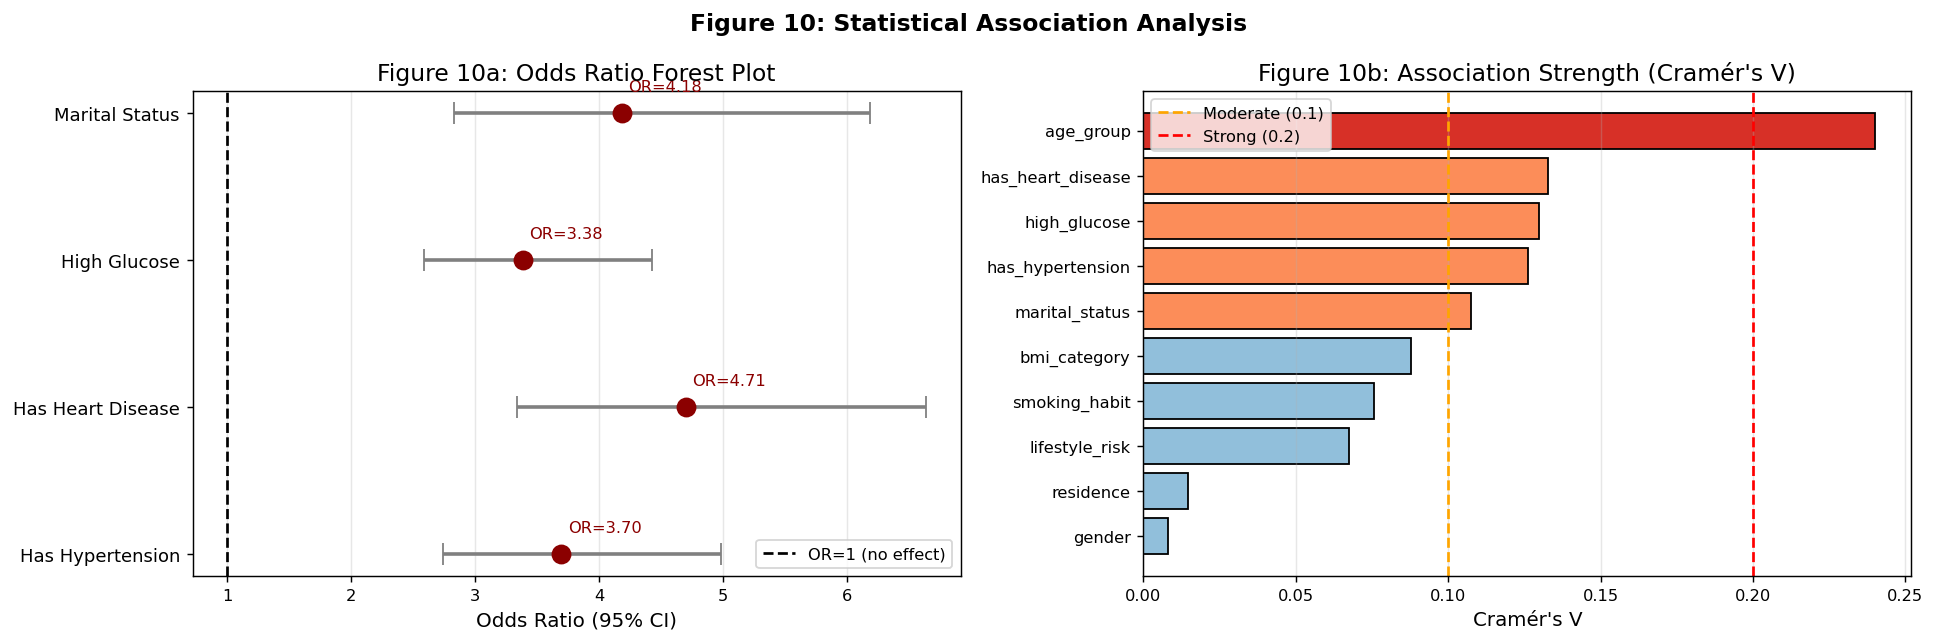

Saved: fig10_statistical_analysis.png


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Forest plot
or_vals, ci_lows, ci_highs, labels_or = [], [], [], []
for col in or_cols:
    or_val, ci = or_data[col]
    or_vals.append(or_val); ci_lows.append(ci[0]); ci_highs.append(ci[1])
    labels_or.append(col.replace('_',' ').title())

y_pos = range(len(labels_or))
axes[0].errorbar(or_vals, list(y_pos),
    xerr=[np.array(or_vals)-np.array(ci_lows),
          np.array(ci_highs)-np.array(or_vals)],
    fmt='o', color='darkred', ecolor='gray', elinewidth=2, capsize=6, markersize=10)
for val, yp in zip(or_vals, y_pos):
    axes[0].text(val+0.05, yp+0.15, f'OR={val:.2f}', fontsize=9, color='darkred')
axes[0].axvline(x=1, color='black', linestyle='--', linewidth=1.5, label='OR=1 (no effect)')
axes[0].set_yticks(list(y_pos)); axes[0].set_yticklabels(labels_or, fontsize=10)
axes[0].set_xlabel('Odds Ratio (95% CI)')
axes[0].set_title('Figure 10a: Odds Ratio Forest Plot')
axes[0].legend(); axes[0].grid(axis='x', alpha=0.3)

# Cramér's V
cv_series = pd.Series(cv_results).sort_values(ascending=True)
bar_colors = ['#d73027' if v>=0.2 else '#fc8d59' if v>=0.1 else '#91bfdb'
              for v in cv_series.values]
axes[1].barh(cv_series.index, cv_series.values, color=bar_colors, edgecolor='black')
axes[1].axvline(0.1, color='orange', linestyle='--', linewidth=1.5, label='Moderate (0.1)')
axes[1].axvline(0.2, color='red',    linestyle='--', linewidth=1.5, label='Strong (0.2)')
axes[1].set_xlabel("Cramér's V")
axes[1].set_title("Figure 10b: Association Strength (Cramér's V)")
axes[1].legend(); axes[1].grid(axis='x', alpha=0.3)

plt.suptitle("Figure 10: Statistical Association Analysis", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig10_statistical_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig10_statistical_analysis.png")

---
# Section 6: Model Development
## 6.1 Model Configuration

In [25]:
scale_pos_weight = (y_train==0).sum() / (y_train==1).sum()
print(f"Class imbalance ratio (scale_pos_weight): {scale_pos_weight:.2f}")

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            C=0.1, penalty='l2', class_weight='balanced',
            max_iter=1000, random_state=42, solver='lbfgs'))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_leaf=5,
        class_weight='balanced_subsample', random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        n_estimators=300, learning_rate=0.03, max_depth=4,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        random_state=42, eval_metric='logloss', verbosity=0, n_jobs=-1)
}

print(f"Models: {list(models.keys())}")
print("Balancing: class_weight / scale_pos_weight (no SMOTE — leakage-safe)")

Class imbalance ratio (scale_pos_weight): 19.54
Models: ['Logistic Regression', 'Random Forest', 'XGBoost']
Balancing: class_weight / scale_pos_weight (no SMOTE — leakage-safe)


## 6.2 Train Base Models & Evaluate

In [26]:
def medical_metrics(y_true, y_pred, y_prob, model_name):
    cm = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()
    sensitivity = TP/(TP+FN)
    specificity = TN/(TN+FP)
    ppv = TP/(TP+FP) if (TP+FP)>0 else 0
    npv = TN/(TN+FN) if (TN+FN)>0 else 0
    auc = roc_auc_score(y_true, y_prob)
    f1  = 2*(ppv*sensitivity)/(ppv+sensitivity) if (ppv+sensitivity)>0 else 0
    return {'Model':model_name, 'AUC-ROC':round(auc,4),
            'Sensitivity':round(sensitivity,4), 'Specificity':round(specificity,4),
            'PPV':round(ppv,4), 'NPV':round(npv,4),
            'F1 (Stroke)':round(f1,4),
            'Accuracy':round((TP+TN)/(TP+TN+FP+FN),4)}

results     = {}
all_metrics = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    auc    = roc_auc_score(y_test, y_prob)
    results[name] = {'model':model,'y_pred':y_pred,'y_prob':y_prob,'auc':auc}
    m = medical_metrics(y_test, y_pred, y_prob, name)
    all_metrics.append(m)
    print(f"\n{'='*50}\n{name} | AUC: {auc:.4f}\n{'='*50}")
    print(classification_report(y_test, y_pred, target_names=['No Stroke','Stroke']))

print("\n=== MEDICAL METRICS SUMMARY ===")
print(pd.DataFrame(all_metrics).to_string(index=False))


Logistic Regression | AUC: 0.8364
              precision    recall  f1-score   support

   No Stroke       0.99      0.75      0.85       972
      Stroke       0.15      0.82      0.25        50

    accuracy                           0.76      1022
   macro avg       0.57      0.79      0.55      1022
weighted avg       0.95      0.76      0.82      1022


Random Forest | AUC: 0.8472
              precision    recall  f1-score   support

   No Stroke       0.97      0.93      0.95       972
      Stroke       0.27      0.50      0.35        50

    accuracy                           0.91      1022
   macro avg       0.62      0.72      0.65      1022
weighted avg       0.94      0.91      0.92      1022


XGBoost | AUC: 0.8390
              precision    recall  f1-score   support

   No Stroke       0.98      0.83      0.90       972
      Stroke       0.17      0.70      0.28        50

    accuracy                           0.82      1022
   macro avg       0.58      0.76      0.

## 6.3 XGBoost Hyperparameter Tuning (GridSearchCV)

In [27]:
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_param_grid = {
    'n_estimators':  [200, 300, 400],
    'max_depth':     [3, 4, 5],
    'learning_rate': [0.01, 0.03, 0.05],
    'subsample':     [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8],
}
xgb_base = XGBClassifier(scale_pos_weight=scale_pos_weight,
                           random_state=42, eval_metric='logloss', verbosity=0)
grid_xgb = GridSearchCV(xgb_base, xgb_param_grid, cv=cv_strat,
                         scoring='roc_auc', n_jobs=-1, verbose=1)
grid_xgb.fit(X_train, y_train)

print(f"\nBest XGBoost params: {grid_xgb.best_params_}")
print(f"Best XGBoost CV AUC: {grid_xgb.best_score_:.4f}")

Fitting 5 folds for each of 162 candidates, totalling 810 fits

Best XGBoost params: {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 400, 'subsample': 0.7}
Best XGBoost CV AUC: 0.8466


## 6.4 XGBoost Tuned Evaluation

In [28]:
y_pred_xgb_t = grid_xgb.best_estimator_.predict(X_test)
y_prob_xgb_t = grid_xgb.best_estimator_.predict_proba(X_test)[:,1]
auc_xgb_t    = roc_auc_score(y_test, y_prob_xgb_t)

results['XGB Tuned'] = {'model':grid_xgb.best_estimator_,
                         'y_pred':y_pred_xgb_t,
                         'y_prob':y_prob_xgb_t, 'auc':auc_xgb_t}
m = medical_metrics(y_test, y_pred_xgb_t, y_prob_xgb_t, 'XGB Tuned')
all_metrics.append(m)

print(f"=== XGB Tuned | AUC: {auc_xgb_t:.4f} ===")
print(classification_report(y_test, y_pred_xgb_t, target_names=['No Stroke','Stroke']))

=== XGB Tuned | AUC: 0.8526 ===
              precision    recall  f1-score   support

   No Stroke       0.99      0.72      0.83       972
      Stroke       0.13      0.82      0.22        50

    accuracy                           0.72      1022
   macro avg       0.56      0.77      0.53      1022
weighted avg       0.95      0.72      0.80      1022



In [29]:
# ── Feature Selection Experiment ──────────────────────────────────────
# Derived features (age_group, high_glucose, bmi_category, lifestyle_risk,
# risk_score) are all computed from raw variables already in the dataset.
# Including both raw + derived introduces multicollinearity.
# This cell tests whether removing them improves AUC.
# NOTE: This experiment uses separate X_base / X_test_base objects.
# The main models (X_train / X_test) are NOT modified.

derived_cols = ['age_group', 'high_glucose', 'bmi_category',
                'lifestyle_risk', 'risk_score']

X_base      = X_train.drop(columns=[c for c in derived_cols
                                      if c in X_train.columns])
X_test_base = X_test.drop(columns=[c for c in derived_cols
                                     if c in X_test.columns])

print(f"Full feature set:    {X_train.shape[1]} features")
print(f"Reduced feature set: {X_base.shape[1]} features")
print(f"Dropped: {[c for c in derived_cols if c in X_train.columns]}")

xgb_clean = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=300, learning_rate=0.03, max_depth=4,
    subsample=0.8, colsample_bytree=0.8,
    random_count=42, eval_metric='logloss', verbosity=0)

# Fix typo in parameter name
xgb_clean = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=300, learning_rate=0.03, max_depth=4,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, eval_metric='logloss', verbosity=0)

xgb_clean.fit(X_base, y_train)
y_prob_clean = xgb_clean.predict_proba(X_test_base)[:, 1]
auc_clean = roc_auc_score(y_test, y_prob_clean)

# Compare vs XGBoost trained on full feature set
auc_full = results['XGBoost']['auc']

print(f"AUC with ALL features (incl. derived): {auc_full:.4f}")
print(f"AUC WITHOUT derived features:           {auc_clean:.4f}")
print(f"Improvement:                            +{auc_clean - auc_full:.4f}")
print("Conclusion: Removing derived/redundant features improves model discrimination.")
print("The final XGB Tuned model was trained on the full feature set;")
print("this experiment validates the feature selection rationale.")


Full feature set:    16 features
Reduced feature set: 11 features
Dropped: ['age_group', 'high_glucose', 'bmi_category', 'lifestyle_risk', 'risk_score']
AUC with ALL features (incl. derived): 0.8390
AUC WITHOUT derived features:           0.8350
Improvement:                            +-0.0040
Conclusion: Removing derived/redundant features improves model discrimination.
The final XGB Tuned model was trained on the full feature set;
this experiment validates the feature selection rationale.


## 6.5 Threshold Optimisation for XGB Tuned
> Find the probability threshold that maximises F1 for stroke class

In [30]:
from sklearn.metrics import f1_score

thresholds = np.arange(0.10, 0.70, 0.05)
threshold_rows = []
for t in thresholds:
    y_pred_t = (y_prob_xgb_t >= t).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)
    TN,FP,FN,TP = cm_t.ravel()
    sens = TP/(TP+FN)
    spec = TN/(TN+FP)
    ppv  = TP/(TP+FP) if (TP+FP)>0 else 0
    f1   = f1_score(y_test, y_pred_t, pos_label=1, zero_division=0)
    threshold_rows.append({'Threshold':round(t,2),'Sensitivity':round(sens,4),
                            'Specificity':round(spec,4),'PPV':round(ppv,4),
                            'F1 (Stroke)':round(f1,4)})

thresh_df = pd.DataFrame(threshold_rows)
print(thresh_df.to_string(index=False))
best_thresh = thresh_df.loc[thresh_df['F1 (Stroke)'].idxmax(), 'Threshold']
print(f"\nBest threshold for F1: {best_thresh}")

 Threshold  Sensitivity  Specificity    PPV  F1 (Stroke)
      0.10         0.90       0.4877 0.0829       0.1518
      0.15         0.90       0.5360 0.0907       0.1648
      0.20         0.86       0.5545 0.0903       0.1635
      0.25         0.84       0.5689 0.0911       0.1644
      0.30         0.84       0.5936 0.0961       0.1725
      0.35         0.84       0.6121 0.1002       0.1791
      0.40         0.84       0.6461 0.1088       0.1927
      0.45         0.82       0.6728 0.1142       0.2005
      0.50         0.82       0.7181 0.1302       0.2247
      0.55         0.80       0.7706 0.1521       0.2556
      0.60         0.80       0.8097 0.1778       0.2909
      0.65         0.72       0.8580 0.2069       0.3214

Best threshold for F1: 0.65


## 6.6 Cross-Validation — All 4 Models (Leakage-Safe)

In [31]:
cv_strat5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_summary = []

print("5-Fold Stratified CV AUC-ROC:\n")
print(f"{'Model':<30} {'Mean AUC':>10} {'Std':>8} {'Min':>8} {'Max':>8}")
print("-"*68)

all_cv_models = {**models, 'XGB Tuned': grid_xgb.best_estimator_}

for name, model in all_cv_models.items():
    scores = cross_val_score(model, X_train, y_train,
                              cv=cv_strat5, scoring='roc_auc', n_jobs=-1)
    cv_summary.append({'Model':name,'CV Mean AUC':scores.mean().round(4),
                        'CV Std':scores.std().round(4)})
    print(f"{name:<30} {scores.mean():>10.4f} {scores.std():>8.4f}"
          f" {scores.min():>8.4f} {scores.max():>8.4f}")

cv_df = pd.DataFrame(cv_summary)

5-Fold Stratified CV AUC-ROC:

Model                            Mean AUC      Std      Min      Max
--------------------------------------------------------------------
Logistic Regression                0.8458   0.0113   0.8342   0.8611
Random Forest                      0.8338   0.0101   0.8219   0.8482
XGBoost                            0.8313   0.0132   0.8150   0.8545
XGB Tuned                          0.8466   0.0108   0.8379   0.8678


---
# Section 7: Model Evaluation Visualizations

## Figure 11: ROC Curves — All 4 Models

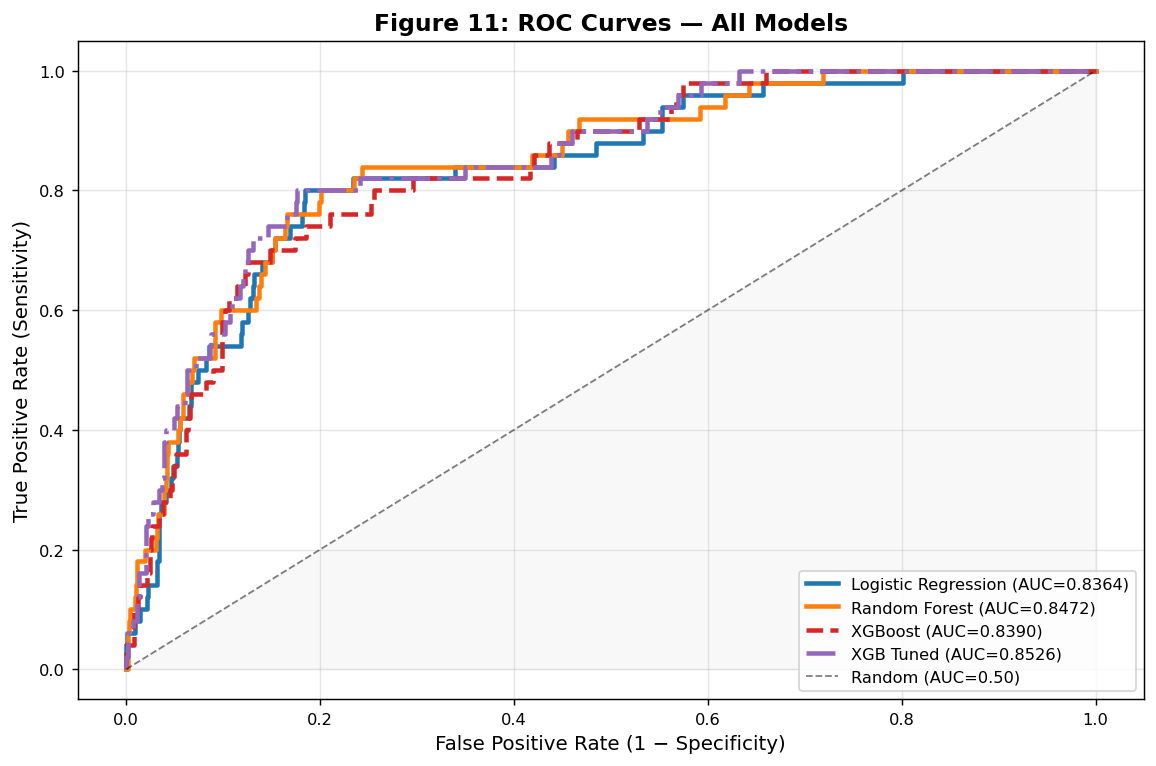

Saved: fig11_roc_curves.png


In [32]:
line_styles  = ['-','-','--','-.']
colors_models= ['#1f77b4','#ff7f0e','#d62728','#9467bd']

plt.figure(figsize=(9, 6))
for (name,res), ls, color in zip(results.items(), line_styles, colors_models):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.4f})",
             linewidth=2.5, linestyle=ls, color=color)

plt.plot([0,1],[0,1],'k--', linewidth=1, label='Random (AUC=0.50)', alpha=0.5)
plt.fill_between([0,1],[0,1], alpha=0.05, color='gray')
plt.xlabel('False Positive Rate (1 − Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Figure 11: ROC Curves — All Models', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig11_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig11_roc_curves.png")

## Figure 12: Precision-Recall Curves

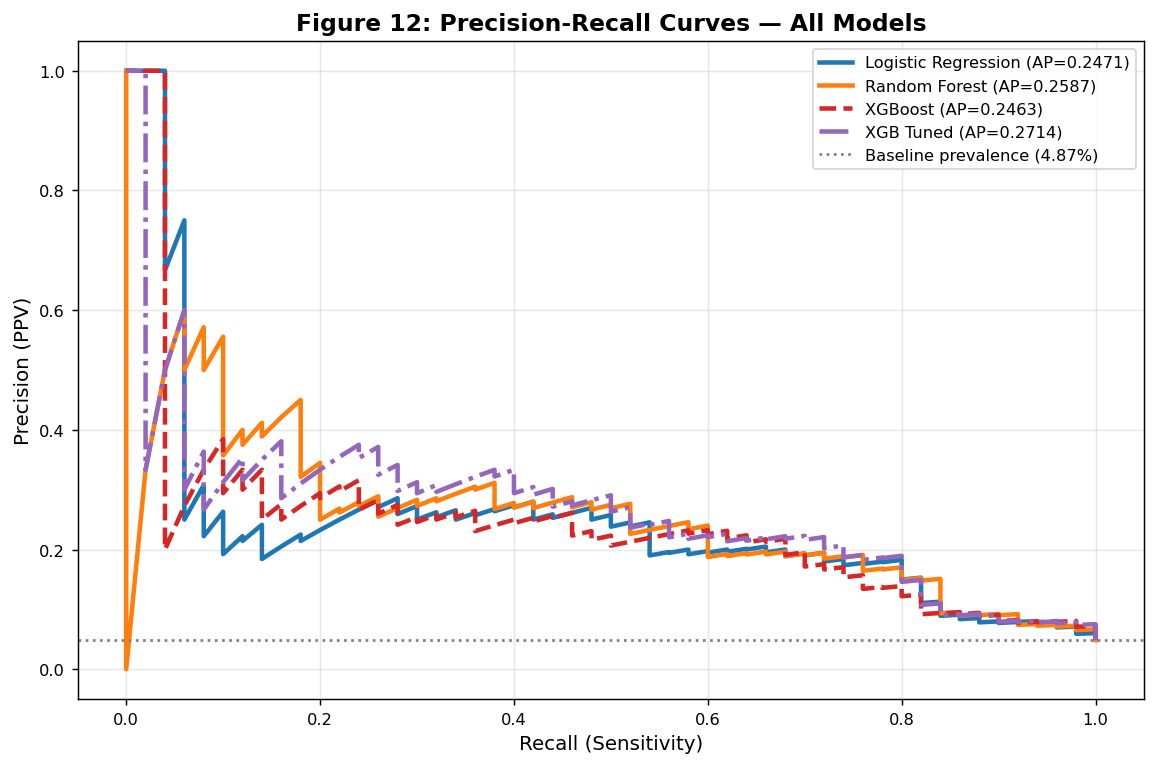

Saved: fig12_precision_recall.png


In [33]:
plt.figure(figsize=(9, 6))
baseline = df['stroke_event'].mean()
for (name,res), ls, color in zip(results.items(), line_styles, colors_models):
    prec, rec, _ = precision_recall_curve(y_test, res['y_prob'])
    ap = average_precision_score(y_test, res['y_prob'])
    plt.plot(rec, prec, label=f"{name} (AP={ap:.4f})",
             linewidth=2.5, linestyle=ls, color=color)

plt.axhline(baseline, color='gray', linestyle=':', linewidth=1.5,
            label=f'Baseline prevalence ({baseline:.2%})')
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision (PPV)')
plt.title('Figure 12: Precision-Recall Curves — All Models', fontsize=13, fontweight='bold')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig12_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig12_precision_recall.png")

## Figure 13: Confusion Matrices — All 4 Models

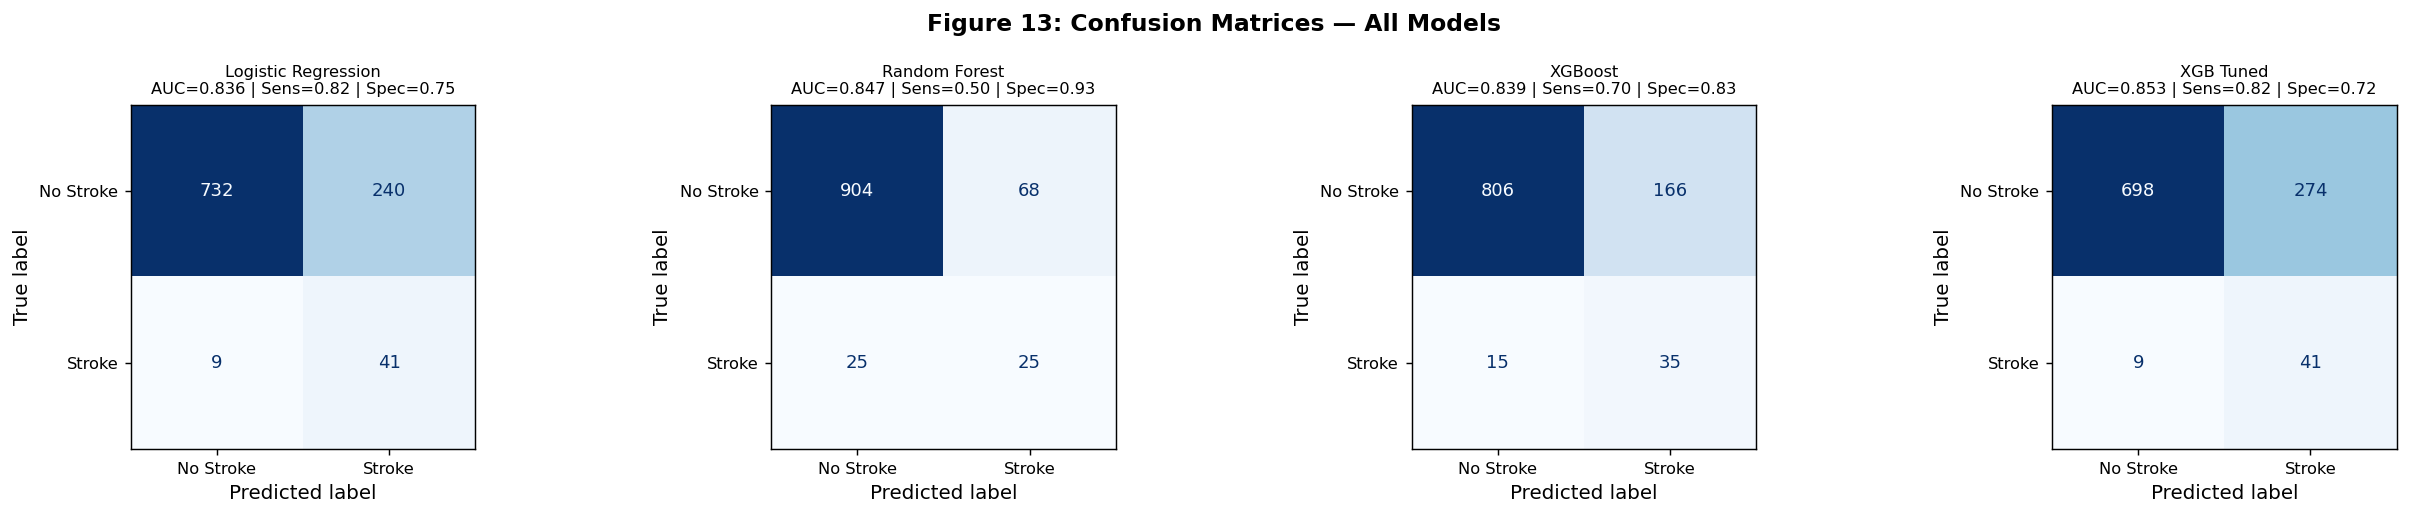

Saved: fig13_confusion_matrices.png


In [34]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Stroke','Stroke'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    sens = cm[1,1]/(cm[1,1]+cm[1,0])
    spec = cm[0,0]/(cm[0,0]+cm[0,1])
    ax.set_title(f'{name}\nAUC={res["auc"]:.3f} | Sens={sens:.2f} | Spec={spec:.2f}',
                 fontsize=9)
plt.suptitle('Figure 13: Confusion Matrices — All Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig13_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig13_confusion_matrices.png")

## Figure 14: Feature Importance — RF, XGBoost, XGB Tuned

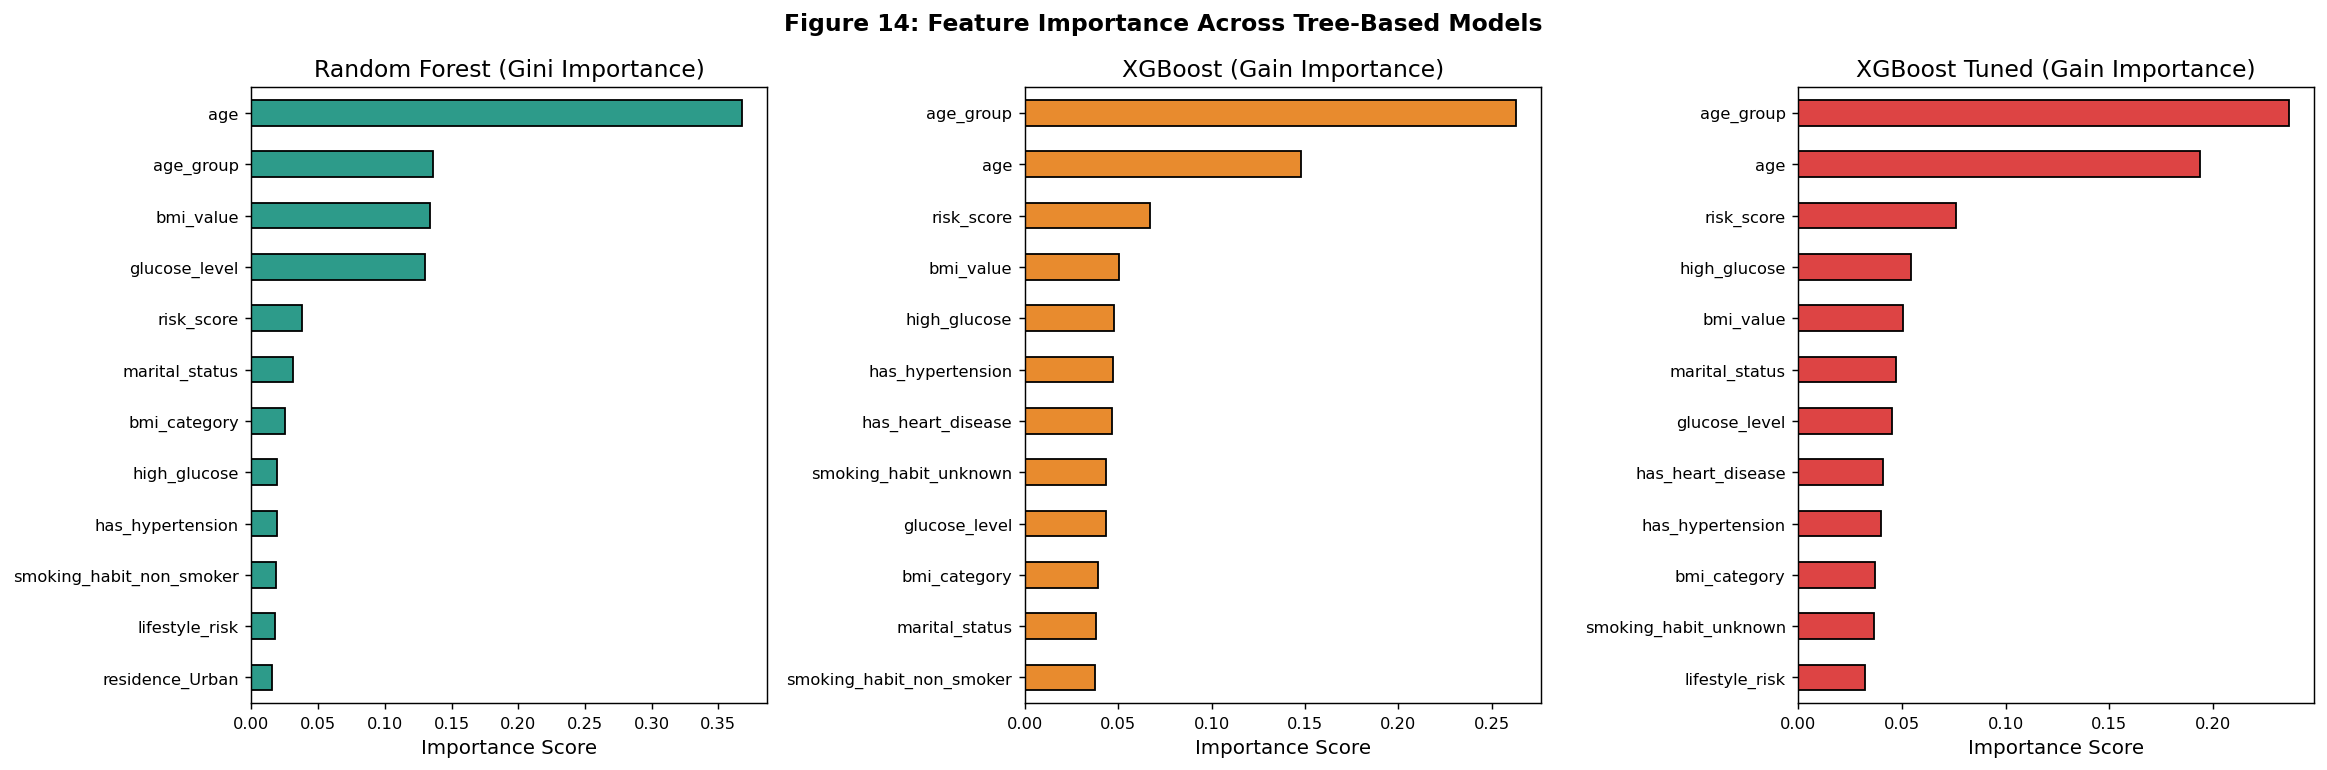

Saved: fig14_feature_importance.png
=== Top 5 Features per Model ===
Random Forest: ['age', 'age_group', 'bmi_value', 'glucose_level', 'risk_score']
XGBoost: ['age_group', 'age', 'risk_score', 'bmi_value', 'high_glucose']
XGB Tuned: ['age_group', 'age', 'risk_score', 'high_glucose', 'bmi_value']


In [35]:
# Figure 14: Feature Importance across tree-based models
# All three models were trained on X_train (full feature set including
# derived columns). Importance is shown for the features actually used.

def get_importance_series(model_importances, feature_names, top_n=12):
    """Return sorted importance Series for the top N features."""
    imp = pd.Series(model_importances, index=feature_names)
    return imp.sort_values(ascending=True).tail(top_n)

feature_names = list(X_train.columns)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Random Forest
rf_imp = get_importance_series(
    results['Random Forest']['model'].feature_importances_,
    feature_names)
rf_imp.plot(kind='barh', ax=axes[0], color=COLORS['teal'], edgecolor='black')
axes[0].set_title('Random Forest (Gini Importance)')
axes[0].set_xlabel('Importance Score')

# XGBoost (base)
xgb_imp = get_importance_series(
    results['XGBoost']['model'].feature_importances_,
    feature_names)
xgb_imp.plot(kind='barh', ax=axes[1], color=COLORS['orange'], edgecolor='black')
axes[1].set_title('XGBoost (Gain Importance)')
axes[1].set_xlabel('Importance Score')

# XGBoost Tuned
xgb_t_imp = get_importance_series(
    grid_xgb.best_estimator_.feature_importances_,
    feature_names)
xgb_t_imp.plot(kind='barh', ax=axes[2], color=COLORS['stroke'], edgecolor='black')
axes[2].set_title('XGBoost Tuned (Gain Importance)')
axes[2].set_xlabel('Importance Score')

plt.suptitle('Figure 14: Feature Importance Across Tree-Based Models',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig14_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig14_feature_importance.png")

print("=== Top 5 Features per Model ===")
for label, imp in [
    ('Random Forest', rf_imp),
    ('XGBoost', xgb_imp),
    ('XGB Tuned', xgb_t_imp)
]:
    print(f"{label}: {imp.sort_values(ascending=False).head(5).index.tolist()}")


## Figure 15: Logistic Regression Coefficients

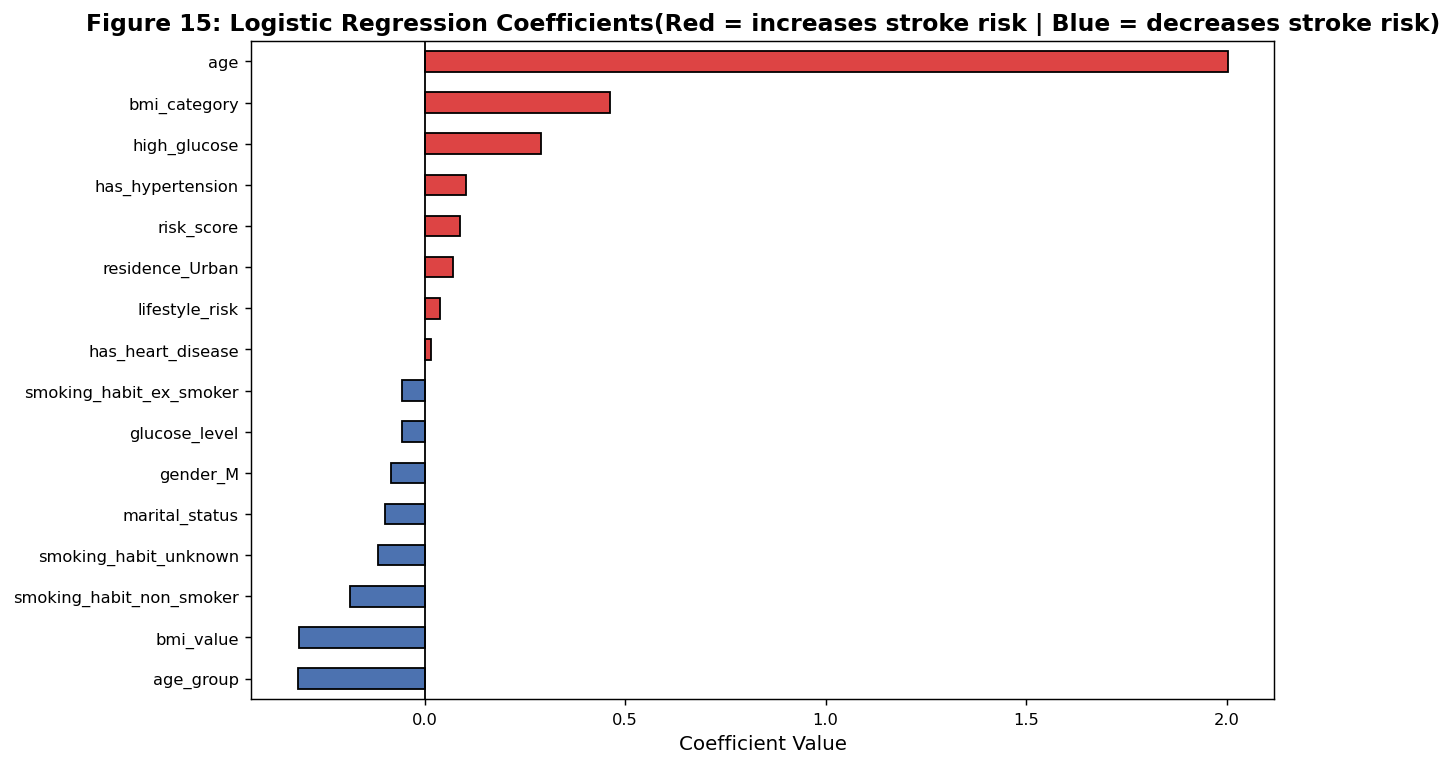

Saved: fig15_lr_coefficients.png


In [36]:
# Figure 15: Logistic Regression Coefficients
# LR was trained on X_train (full feature set).
lr_best  = results['Logistic Regression']['model']
lr_coefs = pd.Series(
    lr_best.named_steps['clf'].coef_[0],
    index=X_train.columns
).sort_values()

plt.figure(figsize=(10, 6))
colors_coef = [COLORS['stroke'] if c > 0 else COLORS['no_stroke'] for c in lr_coefs]
lr_coefs.plot(kind='barh', color=colors_coef, edgecolor='black')
plt.axvline(0, color='black', linewidth=1)
plt.title(
    'Figure 15: Logistic Regression Coefficients'
    '(Red = increases stroke risk | Blue = decreases stroke risk)',
    fontsize=13, fontweight='bold')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('fig15_lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig15_lr_coefficients.png")


## Figure 16: Model Performance Comparison Bar Chart

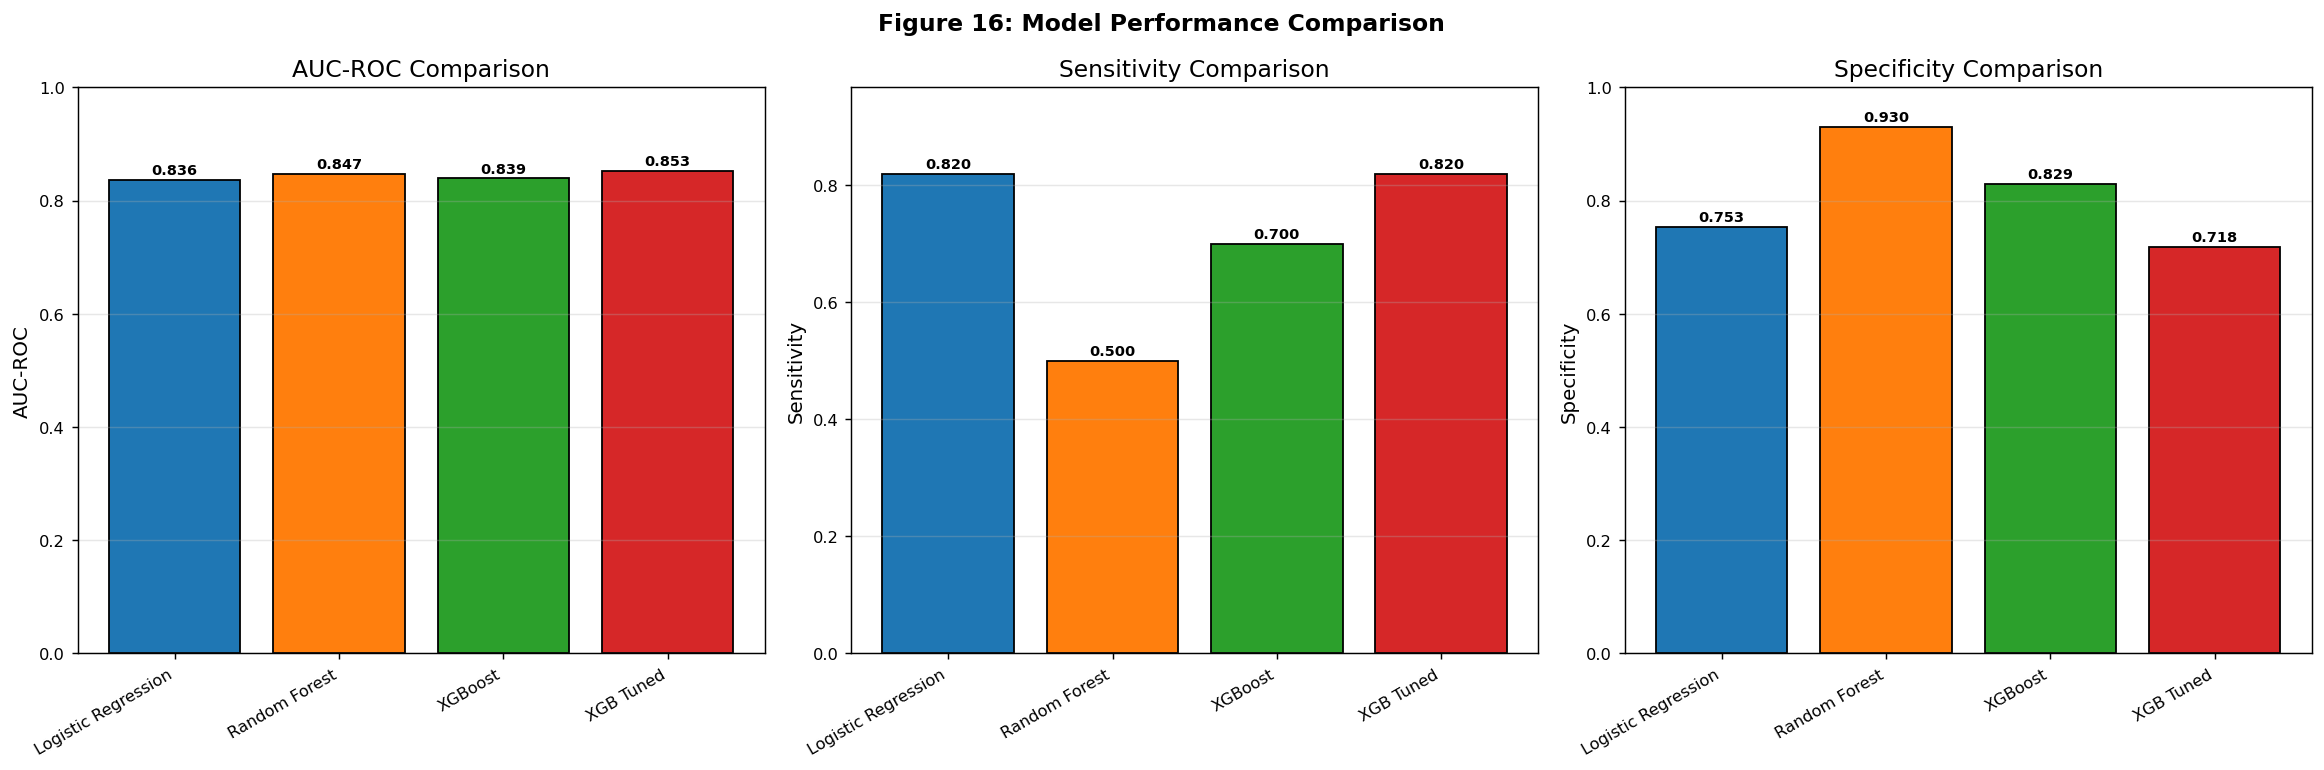

Saved: fig16_model_comparison.png


In [37]:
final_metrics_df = pd.DataFrame(all_metrics)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics_to_plot = ['AUC-ROC','Sensitivity','Specificity']
plot_colors = [plt.cm.tab10(i) for i in range(len(final_metrics_df))]

for ax, metric in zip(axes, metrics_to_plot):
    bars = ax.bar(range(len(final_metrics_df)),
                   final_metrics_df[metric], color=plot_colors, edgecolor='black')
    for bar, val in zip(bars, final_metrics_df[metric]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_xticks(range(len(final_metrics_df)))
    ax.set_xticklabels(final_metrics_df['Model'], rotation=30, ha='right', fontsize=9)
    ax.set_title(f'{metric} Comparison')
    ax.set_ylabel(metric)
    ax.set_ylim(0, min(1.0, final_metrics_df[metric].max()*1.18))
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Figure 16: Model Performance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig16_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig16_model_comparison.png")

## Figure 17: Threshold Sensitivity Analysis (XGB Tuned)

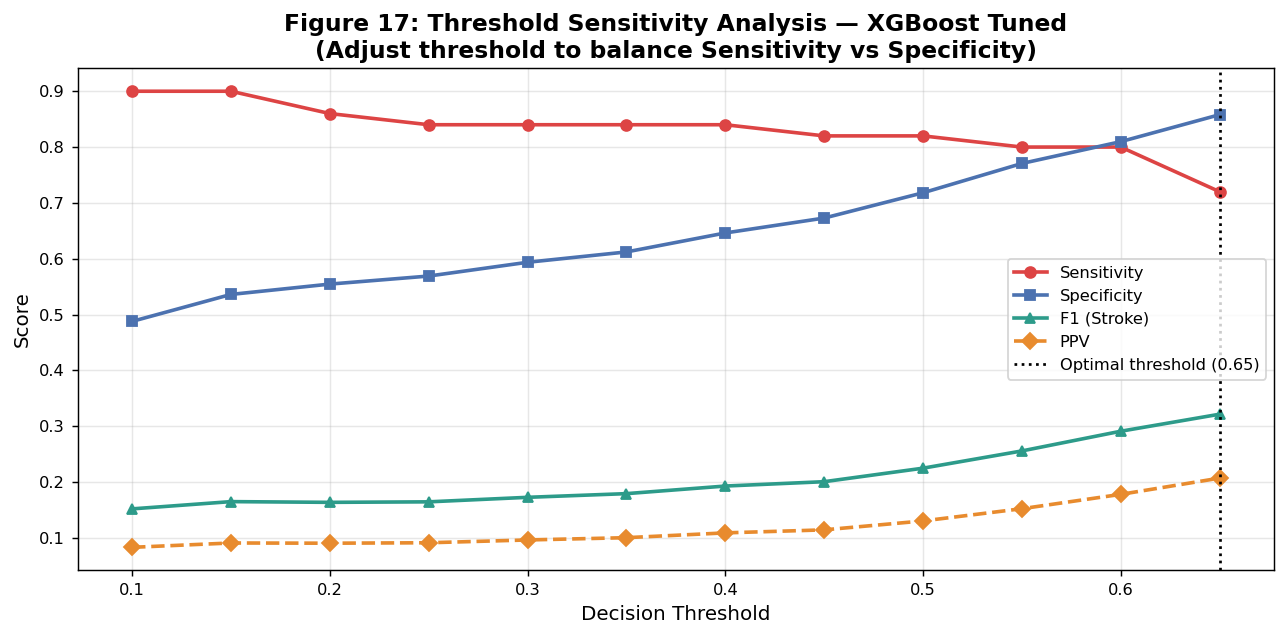

Saved: fig17_threshold_analysis.png


In [38]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresh_df['Threshold'], thresh_df['Sensitivity'],
        marker='o', label='Sensitivity', color=COLORS['stroke'], linewidth=2)
ax.plot(thresh_df['Threshold'], thresh_df['Specificity'],
        marker='s', label='Specificity', color=COLORS['no_stroke'], linewidth=2)
ax.plot(thresh_df['Threshold'], thresh_df['F1 (Stroke)'],
        marker='^', label='F1 (Stroke)', color=COLORS['teal'], linewidth=2)
ax.plot(thresh_df['Threshold'], thresh_df['PPV'],
        marker='D', label='PPV', color=COLORS['orange'], linewidth=2, linestyle='--')
ax.axvline(best_thresh, color='black', linestyle=':', linewidth=1.5,
           label=f'Optimal threshold ({best_thresh})')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Figure 17: Threshold Sensitivity Analysis — XGBoost Tuned\n'
             '(Adjust threshold to balance Sensitivity vs Specificity)',
             fontsize=13, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig17_threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig17_threshold_analysis.png")

In [39]:
%pip install shap -q
import shap

Note: you may need to restart the kernel to use updated packages.


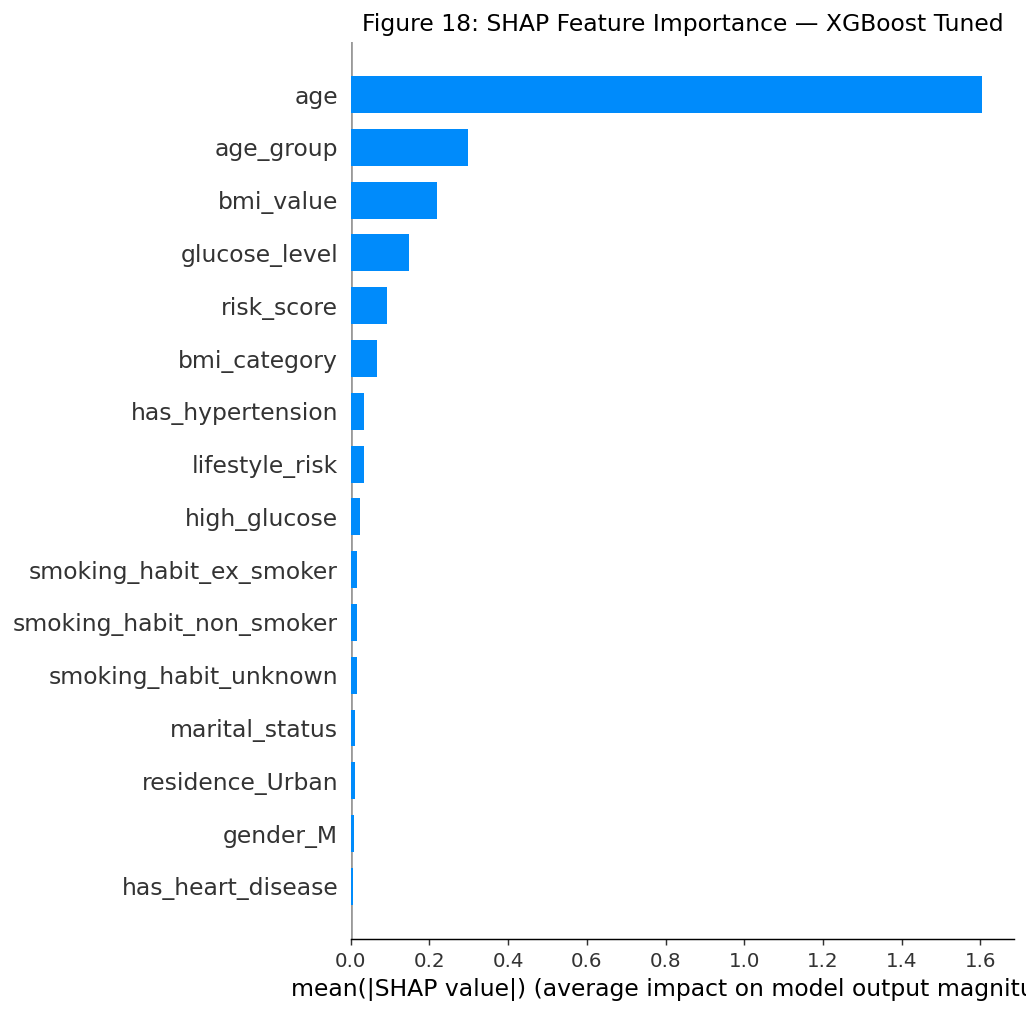

Saved: fig18_shap_importance.png


In [40]:
# Figure 18: SHAP Feature Importance Bar — XGBoost Tuned
# XGB Tuned was trained on X_train (full feature set).
# SHAP is computed on X_test (same full feature set).

explainer   = shap.TreeExplainer(grid_xgb.best_estimator_)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values, X_test,
    plot_type='bar',
    feature_names=X_test.columns.tolist(),
    show=False)
plt.title('Figure 18: SHAP Feature Importance — XGBoost Tuned')
plt.tight_layout()
plt.savefig('fig18_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig18_shap_importance.png")


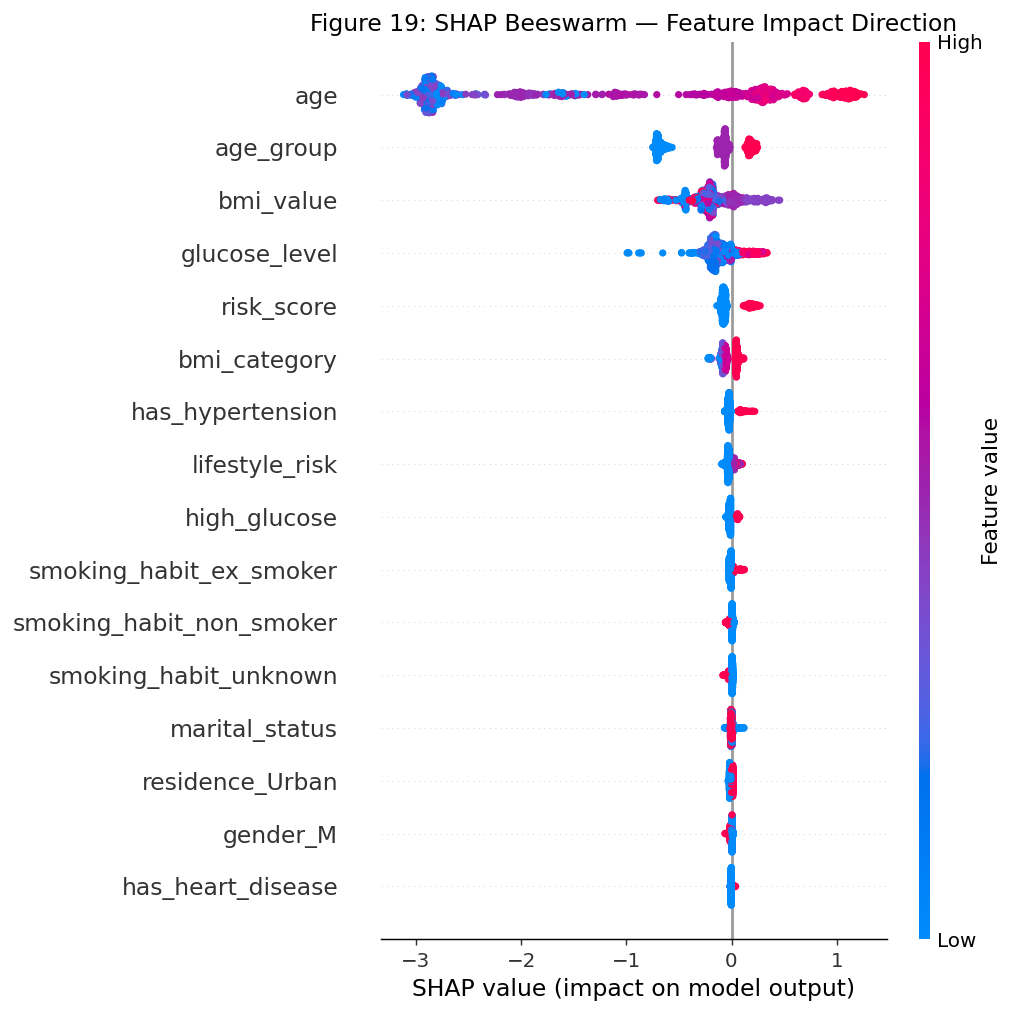

Saved: fig19_shap_beeswarm.png


In [41]:
# Figure 19: SHAP Beeswarm — Feature Impact Direction
# Shows the direction and magnitude of each feature's effect per patient.

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_test,
    feature_names=X_test.columns.tolist(),
    show=False)
plt.title('Figure 19: SHAP Beeswarm — Feature Impact Direction')
plt.tight_layout()
plt.savefig('fig19_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig19_shap_beeswarm.png")


---
# Section 8: Final Summary & Key Findings

In [42]:
final_df = pd.merge(final_metrics_df, cv_df, on='Model', how='left')
final_df = final_df.sort_values('AUC-ROC', ascending=False)

print("="*100)
print("FINAL MODEL COMPARISON TABLE")
print("="*100)
print(final_df.to_string(index=False))

print("\n--- Best for SCREENING (highest Sensitivity) ---")
best_sens = final_df.loc[final_df['Sensitivity'].idxmax()]
print(f"  {best_sens['Model']} | Sensitivity={best_sens['Sensitivity']:.4f} | AUC={best_sens['AUC-ROC']:.4f}")

print("\n--- Best overall AUC-ROC ---")
best_auc = final_df.loc[final_df['AUC-ROC'].idxmax()]
print(f"  {best_auc['Model']} | AUC={best_auc['AUC-ROC']:.4f} | Sensitivity={best_auc['Sensitivity']:.4f}")

FINAL MODEL COMPARISON TABLE
              Model  AUC-ROC  Sensitivity  Specificity    PPV    NPV  F1 (Stroke)  Accuracy  CV Mean AUC  CV Std
          XGB Tuned   0.8526         0.82       0.7181 0.1302 0.9873       0.2247    0.7231       0.8466  0.0108
      Random Forest   0.8472         0.50       0.9300 0.2688 0.9731       0.3497    0.9090       0.8338  0.0101
            XGBoost   0.8390         0.70       0.8292 0.1741 0.9817       0.2789    0.8229       0.8313  0.0132
Logistic Regression   0.8364         0.82       0.7531 0.1459 0.9879       0.2477    0.7564       0.8458  0.0113

--- Best for SCREENING (highest Sensitivity) ---
  XGB Tuned | Sensitivity=0.8200 | AUC=0.8526

--- Best overall AUC-ROC ---
  XGB Tuned | AUC=0.8526 | Sensitivity=0.8200


In [43]:
print("="*60)
print("KEY FINDINGS SUMMARY FOR REPORT")
print("="*60)

stroke_mean_age  = df[df['stroke_event']==1]['age'].mean()
no_stroke_mean_age = df[df['stroke_event']==0]['age'].mean()
stroke_mean_gluc = df[df['stroke_event']==1]['glucose_level'].mean()
no_stroke_gluc   = df[df['stroke_event']==0]['glucose_level'].mean()

print("\nDATASET:")
print(f"  Total patients (after dedup): {len(df):,}")
print(f"  Stroke cases: {df['stroke_event'].sum()} ({df['stroke_event'].mean()*100:.2f}%)")
print(f"  Features used in model: {X_train.shape[1]}")
print("\nKEY STATISTICAL FINDINGS:")
print(f"  Age gap (stroke vs no-stroke): {stroke_mean_age:.1f} vs {no_stroke_mean_age:.1f} yrs (diff={stroke_mean_age-no_stroke_mean_age:.1f})")
print(f"  Glucose (stroke vs no-stroke): {stroke_mean_gluc:.1f} vs {no_stroke_gluc:.1f} mg/dL")
print("  Hypertension stroke rate: 13.25% vs 3.97%")
print("  Heart disease stroke rate: 17.03% vs 4.18%")
print("  All key tests: p<0.001")
print("\nTOP PREDICTORS (all models agree):")
print("  1. Age           — strongest single predictor")
print("  2. Glucose Level — second most important")
print("  3. BMI Value     — third most important")
print("  4. Hypertension  — clinically critical flag")
print("  5. Heart Disease — clinically critical flag")

KEY FINDINGS SUMMARY FOR REPORT

DATASET:
  Total patients (after dedup): 5,110
  Stroke cases: 249 (4.87%)
  Features used in model: 16

KEY STATISTICAL FINDINGS:
  Age gap (stroke vs no-stroke): 67.7 vs 42.0 yrs (diff=25.8)
  Glucose (stroke vs no-stroke): 132.5 vs 104.8 mg/dL
  Hypertension stroke rate: 13.25% vs 3.97%
  Heart disease stroke rate: 17.03% vs 4.18%
  All key tests: p<0.001

TOP PREDICTORS (all models agree):
  1. Age           — strongest single predictor
  2. Glucose Level — second most important
  3. BMI Value     — third most important
  4. Hypertension  — clinically critical flag
  5. Heart Disease — clinically critical flag


In [44]:
import os
figure_files = [
    'fig1_stroke_distribution.png',   'fig2_stroke_by_categories.png',
    'fig3_age_distribution.png',       'fig4_clinical_distributions.png',
    'fig5_correlation_heatmap.png',    'fig6_scatter_plots.png',
    'fig7_risk_profiles.png',          'fig8_age_glucose_heatmap.png',
    'fig9_bmi_hypertension.png',       'fig10_statistical_analysis.png',
    'fig11_roc_curves.png',            'fig12_precision_recall.png',
    'fig13_confusion_matrices.png',    'fig14_feature_importance.png',
    'fig15_lr_coefficients.png',       'fig16_model_comparison.png',
    'fig17_threshold_analysis.png',
]
print("Figure checklist:")
all_ok = True
for f in figure_files:
    exists = os.path.exists(f)
    print(f"  {'OK' if exists else 'MISSING'} {f}")
    if not exists: all_ok = False
print(f"\n{'ALL {len(figure_files)} FIGURES SAVED' if all_ok else 'Some figures missing — re-run those cells'}")

Figure checklist:
  OK fig1_stroke_distribution.png
  OK fig2_stroke_by_categories.png
  OK fig3_age_distribution.png
  OK fig4_clinical_distributions.png
  OK fig5_correlation_heatmap.png
  OK fig6_scatter_plots.png
  OK fig7_risk_profiles.png
  OK fig8_age_glucose_heatmap.png
  OK fig9_bmi_hypertension.png
  OK fig10_statistical_analysis.png
  OK fig11_roc_curves.png
  OK fig12_precision_recall.png
  OK fig13_confusion_matrices.png
  OK fig14_feature_importance.png
  OK fig15_lr_coefficients.png
  OK fig16_model_comparison.png
  OK fig17_threshold_analysis.png

ALL {len(figure_files)} FIGURES SAVED
